# Sydney House Price Estimation under Market Shift

**UTS 32513 Machine Learning — Assignment A2 (Option 2: build an ML system for a practical challenge)**

Student: Hangyu Hu — ID: 14735221 — Year: 2026

Repository: https://github.com/AlexHu1210/uts-ml-a2-sydney-house-price  
Open in Colab: https://colab.research.google.com/github/AlexHu1210/uts-ml-a2-sydney-house-price/blob/main/notebook/UTS_ML_A2_Sydney_House_Price.ipynb

---

## Notebook outline

| # | Section | Maps to A2 criterion |
|---|---------|----------------------|
| 0 | Environment setup | Submission requirement (self-contained) |
| 1 | Data acquisition & first look | A — Task definition (input spec) |
| 2 | Data cleaning & task definition | A — Task definition |
| 3 | Temporal train / validation / test split | C — Proper validation scheme |
| 4 | Evaluation metrics (PPE10, MdAPE, RMSE) & naive baselines | C — Evaluation |
| 5 | Model 1: Ridge regression | B — Model & algorithm |
| 6 | Model 2: Gradient boosting (LightGBM) | B — Model & algorithm |
| 7 | Model 3: MLP (PyTorch) | B — Model & algorithm |
| 8 | Ablations: log target, split strategy, suburb encoding, macro features | B / C |
| 9 | Loss vs. task objective; quantile regression | C — Evaluation & refinement |
| 10 | Error analysis & research question | C — Evaluation & refinement |
| 11 | Deployment: `estimate_price()` for one property, with an interactive estimator (11.3) | A — Deployment interface |

> All sections complete. Runtime on a default Colab CPU: about 3 minutes. To price a property of your own in a year of your choice, run all cells and use the controls at the end of Section 11.

## 0. Environment setup

The A2 specification requires the notebook to be **self-contained**: environment setup, data download and preprocessing must all happen inside the notebook so that a reviewer can press *Run all* on Google Colab.

Everything used here is available on a default Colab runtime except `lightgbm`, which is installed below (the install is skipped if the package is already present).

In [1]:
import importlib, subprocess, sys

def ensure(pkg: str, import_name: str | None = None) -> None:
    """Install `pkg` with pip only if `import_name` cannot be imported."""
    try:
        importlib.import_module(import_name or pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

ensure("lightgbm")

import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn, torch

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

print("python  ", sys.version.split()[0])
print("pandas  ", pd.__version__)
print("numpy   ", np.__version__)
print("sklearn ", sklearn.__version__)
print("torch   ", torch.__version__)

python   3.11.14
pandas   2.1.4
numpy    1.26.4
sklearn  1.2.2
torch    2.12.0


## 1. Data acquisition and first look

### 1.1 Source

`domain_properties.csv` — 11,160 residential property sales in Greater Sydney (Jan 2016 – Jan 2022) scraped from Domain.com.au, enriched with suburb-level census statistics and two macro-economic series (RBA cash rate, property price index). Original dataset: *Sydney House Prices*, Kaggle user `alexlau203`, https://www.kaggle.com/datasets/alexlau203/sydney-house-prices

The cell below first looks for a local copy (for offline development) and otherwise downloads the file from `DATA_URL`, a public copy in this project's GitHub repository, so the notebook runs on a fresh Colab session.

In [2]:
import urllib.request
from pathlib import Path

DATA_URL = "https://raw.githubusercontent.com/AlexHu1210/uts-ml-a2-sydney-house-price/main/data/domain_properties.csv"

LOCAL_CANDIDATES = [Path("../data/domain_properties.csv"), Path("data/domain_properties.csv")]
TARGET = Path("domain_properties.csv")

def get_data_path() -> Path:
    for p in LOCAL_CANDIDATES:
        if p.exists():
            print(f"Using local copy: {p.resolve()}")
            return p
    if not TARGET.exists():
        print(f"Downloading from {DATA_URL} ...")
        urllib.request.urlretrieve(DATA_URL, TARGET)
    print(f"Using downloaded copy: {TARGET.resolve()}")
    return TARGET

raw = pd.read_csv(get_data_path())
print("shape:", raw.shape)
raw.head()

Using local copy: /Users/huhangyu/PycharmProjects/32513/data/domain_properties.csv
shape: (11160, 17)


,price,date_sold,suburb,num_bath,num_bed,num_parking,property_size,type,suburb_population,suburb_median_income,suburb_sqkm,suburb_lat,suburb_lng,suburb_elevation,cash_rate,property_inflation_index,km_from_cbd
0,530000,13/1/16,Kincumber,4,4,2,1351,House,7093,29432,9.914,-33.47252,151.40208,24,2.0,150.9,47.05
1,525000,13/1/16,Halekulani,2,4,2,594,House,2538,24752,1.397,-33.21772,151.55237,23,2.0,150.9,78.54
2,480000,13/1/16,Chittaway Bay,2,4,2,468,House,2028,31668,1.116,-33.32678,151.44557,3,2.0,150.9,63.59
3,452000,13/1/16,Leumeah,1,3,1,344,House,9835,32292,4.055,-34.05375,150.83957,81,2.0,150.9,40.12
4,365500,13/1/16,North Avoca,0,0,0,1850,Vacant land,2200,45084,1.497,-33.45608,151.43598,18,2.0,150.9,49.98


### 1.2 What is in the table?

This is **not** exploratory analysis for decoration. Each check below answers a question that the *task definition* (criterion A) needs:

1. What is the type, unit and value range of every input column? (needed for a *Clear*-level input specification)
2. Are there missing values? (decides whether an imputation step is part of the system)
3. How are sales distributed over time? (decides the train/validation/test split)
4. What property types are present? (decides which rows are inside the scope of the task)

In [3]:
# (1) column types and value ranges
summary = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "n_unique": raw.nunique(),
    "n_missing": raw.isna().sum(),
    "min": raw.min(numeric_only=True),
    "median": raw.median(numeric_only=True),
    "max": raw.max(numeric_only=True),
})
summary

,dtype,n_unique,n_missing,min,median,max
cash_rate,float64,14,0,0.10000,1.100000e-01,2.000000e+00
date_sold,object,1338,0,NaN,NaN,NaN
km_from_cbd,float64,595,0,0.31000,2.231000e+01,8.479000e+01
num_bath,int64,17,0,0.00000,2.000000e+00,4.600000e+01
num_bed,int64,25,0,0.00000,4.000000e+00,4.700000e+01
num_parking,int64,20,0,0.00000,2.000000e+00,5.000000e+01
price,int64,2186,0,225000.00000,1.388000e+06,6.000000e+07
property_inflation_index,float64,23,0,150.90000,1.766000e+02,2.201000e+02
property_size,int64,1620,0,7.00000,6.000000e+02,5.910000e+04
suburb,object,637,0,NaN,NaN,NaN


In [4]:
# (3) distribution of sales over time
raw["date_sold"] = pd.to_datetime(raw["date_sold"], format="%d/%m/%y")

print("date range:", raw["date_sold"].min().date(), "->", raw["date_sold"].max().date())
print("\nsales per year:")
print(raw["date_sold"].dt.year.value_counts().sort_index().to_string())

# macro series over time — are they really time-varying?
macro = raw.groupby(raw["date_sold"].dt.year)[["cash_rate", "property_inflation_index"]].agg(["min", "max"])
print("\ncash rate and price index by year:")
print(macro.to_string())

date range: 2016-01-13 -> 2022-01-01

sales per year:
date_sold
2016    1031
2017     998
2018    1010
2019    1159
2020    1632
2021    5328
2022       2

cash rate and price index by year:
          cash_rate       property_inflation_index       
                min   max                      min    max
date_sold                                                
2016           1.50  2.00                    150.9  172.7
2017           1.50  1.50                    171.9  176.6
2018           1.50  1.50                    154.2  171.9
2019           0.75  1.50                    153.5  169.6
2020           0.10  0.75                    165.9  183.1
2021           0.10  0.10                    183.1  220.1
2022           0.10  0.10                    220.1  220.1


In [5]:
# (4) property types and suburb coverage
print(raw["type"].value_counts().to_string())
print("\nnumber of suburbs:", raw["suburb"].nunique())
print("sales per suburb — median:", raw["suburb"].value_counts().median(),
      "| min:", raw["suburb"].value_counts().min(),
      "| max:", raw["suburb"].value_counts().max())

type
House                            9583
Apartment / Unit / Flat           688
Townhouse                         211
Semi-Detached                     170
Vacant land                       163
Villa                             114
Duplex                             67
Terrace                            63
Block of Units                     37
Acreage / Semi-Rural               21
New House & Land                   15
New Apartments / Off the Plan       9
Development Site                    7
Studio                              5
Rural                               4
New land                            3

number of suburbs: 637
sales per suburb — median: 16.0 | min: 1 | max: 68


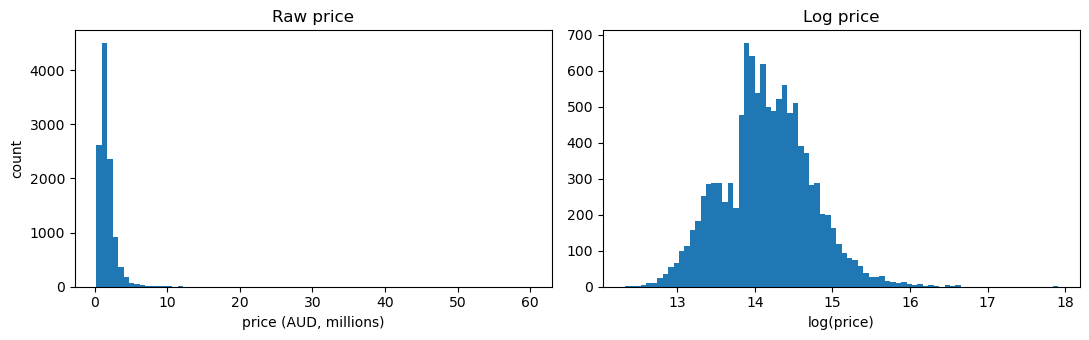

count        11,160
mean      1,675,395
std       1,290,371
min         225,000
25%       1,002,000
50%       1,388,000
75%       2,020,000
max      60,000,000


In [6]:
# Target distribution: raw price vs log price.
# This single figure motivates two later design decisions (log target, relative-error metric).
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(raw["price"] / 1e6, bins=80)
ax[0].set_xlabel("price (AUD, millions)"); ax[0].set_ylabel("count"); ax[0].set_title("Raw price")
ax[1].hist(np.log(raw["price"]), bins=80)
ax[1].set_xlabel("log(price)"); ax[1].set_title("Log price")
plt.tight_layout(); plt.show()

print(raw["price"].describe().apply(lambda v: f"{v:,.0f}").to_string())

### 1.3 What I take from this table

These points are the ones I will use in the report. Each one is tied to a number printed above.

* **The table is complete but not clean.** 11,160 sales, 17 columns, zero missing values, so I do not need an imputation step. The problems are impossible values, not blanks.
* **Price is the label, and it is heavily skewed.** Median sale price is 1,388,000 AUD. The cheapest sale is 225,000 AUD and the most expensive is 60,000,000 AUD. The raw-price histogram is a spike near 1 million with a long right tail. `log(price)` looks much closer to a bell shape, so I will train on `log(price)` and judge the model by relative error, not by raw dollar error.
* **A house is described by five fields.** Bedroom, bathroom and parking counts, land size in square metres, and a type. About 86% of rows are `House` (9,583 of 11,160). The maxima are not believable: 47 bedrooms, 46 bathrooms, and a house listed as 7 m². Those rows are entry errors and are removed in Section 2.
* **Location is only as precise as the suburb.** `suburb_lat` and `suburb_lng` are the suburb centre, so every sale in Mosman gets the same coordinates. There are 637 suburbs and a typical suburb has only 16 sales (minimum 1, maximum 68). I cannot learn a street-level price from this.
* **The market moved inside the file.** The cash rate goes from 2.0% in 2016 down to 0.1% in 2020–2021. The property price index goes from about 166 early in 2020 to 220.1 in late 2021, roughly a one-third rise.
* **2021 is half the data and it is the boom year.** Year counts are 2016: 1,031; 2017: 998; 2018: 1,010; 2019: 1,159; 2020: 1,632; 2021: 5,328; 2022: 2. If I train on 2016–2020 and test on 2021, the test set is a different market. That is the situation a deployed valuer would face, so that is the split I want.
* **One feature may not be known on the day of the sale.** `property_inflation_index` looks like a quarterly index. Quarterly indexes are usually published after the quarter ends, so the value sitting on a sale row might not have been public yet. I have not confirmed the publication lag. I will test a model with and without this column before trusting it.

## System overview

One pass through the system, from file to price. Section numbers point to the code.

```
domain_properties.csv  (11,160 sales)                                        §1
        │  parse dates; drop non-dwellings and implausible rows → 10,864      §2
        ▼
split by sale date:  train < 2021  |  validation 2021 H1  |  test 2021 H2    §3
        │
        ▼
target  =  log(price) − log(price index)          ← the market level is supplied, not learned   §8
inputs  =  bedrooms, bathrooms, parking, land size, type
           + suburb-level: population, income, area, lat/lng, elevation, km to CBD
        │
        ▼
LightGBM, 15 leaves, squared error, early stopping on validation  →  620 trees               §6, §8
quantile LightGBM (pinball loss, τ = 0.1 … 0.9)  →  interval and lending value                §9
        │
        ▼
exp( prediction + log(index) )  →  price in AUD                                              §8
        │
        ▼
estimate_price(bed, bath, parking, size, type, suburb, index)  →  estimate, 80% interval, q25  §11
```

Everything above the target line is shared by all models compared in Sections 4–7 (rule baselines, Ridge, LightGBM on log price, MLP). Model and design choices are made on the validation period only; the test period is scored once per model (Section 4 `record`).


## 2. Task definition and cleaning

### 2.1 What the system must do

**Task.** Given the attributes of one Greater Sydney residential property that are known at (or before) the sale, estimate the sale price in AUD.

This is a **supervised regression** task: every training row has a numeric label `price`.

**Training interface**

| | Specification |
|---|----------------|
| Input | One row: property attributes (`num_bed`, `num_bath`, `num_parking`, `property_size`, `type`), suburb attributes (`suburb`, `suburb_population`, `suburb_median_income`, `suburb_sqkm`, `suburb_lat`, `suburb_lng`, `suburb_elevation`, `km_from_cbd`), sale timing (`date_sold`, later split into year and month), and two macro series (`cash_rate`, `property_inflation_index`). |
| Label | `price`: a positive integer, the recorded sale price in AUD. The model is trained on `log(price)` (justified in Section 1.3 and checked empirically later). |
| One example | A 4-bed, 2-bath house of 594 m² in Halekulani, sold 2016-01-13, 78.5 km from the CBD → label 525,000. |

**Deployment interface**

| | Specification |
|---|----------------|
| Input | The same features for a property that has **not** sold yet. `property_inflation_index` must be the latest *already published* value, not a future one (possible leakage; tested in a later section). |
| Output | A point estimate of the sale price in AUD, obtained by predicting `log(price)` and exponentiating, plus a q10–q90 interval and a conservative lending value from the quantile models (Section 9). Implemented as `estimate_price()` in Section 11. |

**Why a model, and why now.** Estimating what a home would sell for is a routine task for banks (mortgage security), for buyers and sellers, and for listing portals. The industry answer is an *automated valuation model* (AVM): a statistical model that maps property attributes and location to a price estimate. Domain (the source of this file), CoreLogic and PropTrack all publish AVM estimates for Australian homes, and lenders use AVMs to approve loans without a physical valuation. The IAAO *Standard on Automated Valuation Models* (2018) describes how such models are tested: mainly by the spread of the ratio *estimate / sale price*, not by dollar error. Zillow reports its Zestimate accuracy as the share of sales within 10% of the estimate. Section 4 adopts that style of metric.

**Why a fixed rule is not enough.** The same 4-bedroom house sells for about 0.5 M AUD on the Central Coast and above 10 M AUD near the harbour, and the whole market moved by roughly a third between early 2020 and late 2021. A suburb-median rule ignores the dwelling itself; a per-square-metre rule ignores the suburb; and neither updates when the cash rate changes. A human valuer cannot reprice 10,000 properties each quarter. There are, however, 10,864 labelled sales with the attributes a valuer would look at, which is the condition supervised learning needs.

**The research question.** The market in the test period is more expensive than any period in the training data (Section 3). *Can a model fitted to 2016–2020 sales price the 2021 market, and do the macro inputs (`cash_rate`, `property_inflation_index`) or an index-adjusted target reduce the error caused by that shift?* This is the practical failure mode of a deployed AVM, and the time split lets it be measured directly.

**Scope (what is a valid input).** A single residential dwelling: house, apartment, townhouse, semi, villa, duplex, terrace, studio, or a new dwelling of those kinds. Vacant land, development sites, whole blocks of units and rural acreage are a different valuation task and are removed below.


In [7]:
RESIDENTIAL_TYPES = [
    "House",
    "Apartment / Unit / Flat",
    "Townhouse",
    "Semi-Detached",
    "Villa",
    "Duplex",
    "Terrace",
    "Studio",
    "New House & Land",
    "New Apartments / Off the Plan",
]

# Bounds sit well above a normal dwelling and below the obvious entry errors
# (47 bedrooms, 7 m2, a 20,695 m2 "apartment").
RULES = {
    "num_bed": (0, 10),
    "num_bath": (0, 8),
    "num_parking": (0, 8),
    "property_size": (20, 10_000),   # square metres
}

def clean(df: pd.DataFrame) -> pd.DataFrame:
    """Return residential sales with plausible physical attributes.

    Each rule is applied in order and the number of rows it removes is printed,
    so the effect of every decision is visible rather than hidden inside one filter.
    """
    out = df.copy()
    n = len(out)
    out = out[out["type"].isin(RESIDENTIAL_TYPES)]
    print(f"type in {RESIDENTIAL_TYPES[0]!r} ... : {n} -> {len(out)}  (removed {n - len(out)})")

    for col, (lo, hi) in RULES.items():
        n = len(out)
        out = out[out[col].between(lo, hi)]
        print(f"{col} in [{lo}, {hi}]: {n} -> {len(out)}  (removed {n - len(out)})")

    return out.reset_index(drop=True)

sales = clean(raw)
print(f"\nkept {len(sales)} / {len(raw)} rows ({100 * len(sales) / len(raw):.1f}%)")


type in 'House' ... : 11160 -> 10925  (removed 235)
num_bed in [0, 10]: 10925 -> 10903  (removed 22)
num_bath in [0, 8]: 10903 -> 10902  (removed 1)
num_parking in [0, 8]: 10902 -> 10874  (removed 28)
property_size in [20, 10000]: 10874 -> 10864  (removed 10)

kept 10864 / 11160 rows (97.3%)


### 2.2 What each rule is for

* **Property type.** *Vacant land*, *New land*, *Development Site*, *Rural*, *Acreage / Semi-Rural* and *Block of Units* are not one dwelling with a bedroom count. Keeping them would mix two different prediction problems into one loss.
* **Bedroom / bathroom / parking caps.** Values such as 47 bedrooms or 20 bathrooms on one "house" are entry errors (or whole buildings mislabelled as one house). The caps 10 / 8 / 8 are above any ordinary dwelling in this file and below those errors.
* **Land size 20–10,000 m².** 7 m² and 11 m² houses are not real lots. Sizes above 10,000 m² are either entry errors (a 20,695 m² apartment) or acreage, which was excluded with the rural types. Legitimate large suburban lots (up to about 1 hectare) are kept.
* **Price is not capped.** A 17 M AUD Woollahra house with 3 bedrooms is a real sale, not a typo. The log target (later) stops these rows from dominating squared error, which is preferable to deleting them.

Rows removed: 235 (type) + 22 (beds) + 1 (baths) + 28 (parking) + 10 (size) = **296**. **10,864** sales remain.


### 2.3 Input specification after cleaning

One row is one sale. The table below is produced from `sales`, so the ranges are the actual ranges the model will see. Units and notes are what a third party needs to build a valid input.


In [8]:
UNITS_NOTES = {
    "num_bed":                  ("count",            "bedrooms; 0 allowed for studios"),
    "num_bath":                 ("count",            "bathrooms"),
    "num_parking":              ("count",            "car spaces"),
    "property_size":            ("m²",               "land area for houses; strata/floor area for units"),
    "type":                     ("category",         "one of 10 residential types (86% House)"),
    "suburb":                   ("category",         "636 suburbs; typical suburb has ~16 sales"),
    "suburb_population":        ("persons",          "census figure, suburb level (census year not stated by source)"),
    "suburb_median_income":     ("AUD / year",       "census figure, suburb level (census year not stated by source)"),
    "suburb_sqkm":              ("km²",              "suburb area"),
    "suburb_lat":               ("degrees",          "suburb centroid, NOT the property"),
    "suburb_lng":               ("degrees",          "suburb centroid, NOT the property"),
    "suburb_elevation":         ("m",                "suburb level"),
    "km_from_cbd":              ("km",               "suburb centroid to Sydney CBD"),
    "date_sold":                ("date",             "day/month/year; split into year and month"),
    "cash_rate":                ("% p.a.",           "RBA cash rate on the sale date; macro input"),
    "property_inflation_index": ("index",            "quarterly price index; possible publication lag"),
    "price":                    ("AUD",              "LABEL. Model is fit to log(price)"),
}

rows = []
for col, (unit, note) in UNITS_NOTES.items():
    s = sales[col]
    if col in ("type", "suburb"):
        rng = f"{s.nunique()} categories"
    elif col == "date_sold":
        rng = f"{s.min().date()} to {s.max().date()}"
    else:
        rng = f"{s.min():,} to {s.max():,}" if str(s.dtype).startswith("int") else f"{s.min():g} to {s.max():g}"
    rows.append({"column": col, "dtype": str(s.dtype), "unit": unit, "range after cleaning": rng, "note": note})

spec = pd.DataFrame(rows)
with pd.option_context("display.max_colwidth", 60):
    display(spec)


,column,dtype,unit,range after cleaning,note
0,num_bed,int64,count,0 to 10,bedrooms; 0 allowed for studios
1,num_bath,int64,count,0 to 7,bathrooms
2,num_parking,int64,count,0 to 8,car spaces
3,property_size,int64,m²,"29 to 10,000",land area for houses; strata/floor area for units
4,type,object,category,10 categories,one of 10 residential types (86% House)
5,suburb,object,category,636 categories,636 suburbs; typical suburb has ~16 sales
6,suburb_population,int64,persons,"22 to 47,176","census figure, suburb level (census year not stated by s..."
7,suburb_median_income,int64,AUD / year,"14,248 to 97,500","census figure, suburb level (census year not stated by s..."
8,suburb_sqkm,float64,km²,0.089 to 87.154,suburb area
9,suburb_lat,float64,degrees,-34.1062 to -33.1638,"suburb centroid, NOT the property"


In [9]:
# Sale timing as model inputs. Year and month are known on the day of the sale,
# so they are valid at deployment ("what would this sell for this month?").
sales["year"] = sales["date_sold"].dt.year
sales["month"] = sales["date_sold"].dt.month

print(sales[["date_sold", "year", "month", "type", "num_bed", "property_size", "suburb", "price"]].head(3).to_string(index=False))
print("\nyear counts:")
print(sales["year"].value_counts().sort_index().to_string())


 date_sold  year  month  type  num_bed  property_size        suburb  price
2016-01-13  2016      1 House        4           1351     Kincumber 530000
2016-01-13  2016      1 House        4            594    Halekulani 525000
2016-01-13  2016      1 House        4            468 Chittaway Bay 480000

year counts:
year
2016     984
2017     964
2018     982
2019    1122
2020    1577
2021    5233
2022       2


## 3. Train, validation and test split

A deployed valuation model is trained on sales that have already happened and is asked for a price **later**. The split has to copy that order.

| Split | Sale date | Role |
|-------|-----------|------|
| Train | before 2021-01-01 | Fit the model. |
| Validation | 2021-01-01 to 2021-06-30 | Choose the model, the features and the hyperparameters. |
| Test | on or after 2021-07-01 | Report the final number **once**. Not used for any choice. |

2021 is the boom year in this file (cash rate 0.1%, price index up to 220). Putting it entirely in the test set would leave no boom data for model choice, so the first half of 2021 is validation and the second half is test. The two sales dated 2022-01-01 stay in the test set.

A random split is the wrong check. About half of all rows are from 2021, so a random 60% training sample still contains 2021 sales. The model then trains on the high-price market it is supposed to be tested on. That is leakage of the future into the past, and it makes the error look smaller than a real deployment.


In [10]:
TRAIN_END = "2021-01-01"
VAL_END = "2021-07-01"

def split_by_time(df: pd.DataFrame):
    """Past sales for training, early 2021 for validation, later sales for test."""
    train = df[df["date_sold"] < TRAIN_END]
    val = df[(df["date_sold"] >= TRAIN_END) & (df["date_sold"] < VAL_END)]
    test = df[df["date_sold"] >= VAL_END]
    return train.copy(), val.copy(), test.copy()

train, val, test = split_by_time(sales)

def describe_split(name, part):
    return {
        "split": name,
        "rows": len(part),
        "from": part["date_sold"].min().date().isoformat(),
        "to": part["date_sold"].max().date().isoformat(),
        "median_price": int(part["price"].median()),
        "mean_price": int(part["price"].mean()),
    }

time_table = pd.DataFrame([
    describe_split("train", train),
    describe_split("validation", val),
    describe_split("test", test),
])
print(time_table.to_string(index=False))
print("row check:", len(train) + len(val) + len(test), "==", len(sales))


     split  rows       from         to  median_price  mean_price
     train  5629 2016-01-13 2020-12-30       1110000     1379605
validation  1328 2021-01-13 2021-06-30       1731000     2024864
      test  3907 2021-07-13 2022-01-01       1645000     1959304
row check: 10864 == 10864


In [11]:
# Same row counts, but the rows are shuffled. This is the split we will NOT use.
# It shows how many post-2020 sales would leak into training.
shuffled = sales.sample(frac=1, random_state=SEED)
n_train = len(train)
random_train = shuffled.iloc[:n_train]
leaked = random_train["date_sold"] >= TRAIN_END

compare = pd.DataFrame([
    {
        "training set": "time split (used)",
        "rows": len(train),
        "share sold in 2021 or later": 0.0,
        "median price": int(train["price"].median()),
    },
    {
        "training set": "random split (not used)",
        "rows": len(random_train),
        "share sold in 2021 or later": round(float(leaked.mean()), 3),
        "median price": int(random_train["price"].median()),
    },
])
print(compare.to_string(index=False))
print(
    "\nValidation and test medians are",
    int(val["price"].median()), "and", int(test["price"].median()),
    "AUD. The time-split training median is", int(train["price"].median()),
    "AUD, so the model has to predict a more expensive market than it was trained on.",
)


           training set  rows  share sold in 2021 or later  median price
      time split (used)  5629                        0.000       1110000
random split (not used)  5629                        0.471       1375000

Validation and test medians are 1731000 and 1645000 AUD. The time-split training median is 1110000 AUD, so the model has to predict a more expensive market than it was trained on.


### 3.1 What this split says

* Training median is about **1.11 M AUD**. Validation median is about **1.73 M AUD** and test median is about **1.65 M AUD**. The gap is the 2021 price jump, not a sampling accident.
* A random training set of the same size still contains about **47%** sales from 2021 or later, and its median rises to about **1.38 M AUD**. That median is closer to the test set only because the future has been mixed in.
* Every later experiment uses `train`, `val` and `test` from `split_by_time`. The random split is reported here as the leakage check and is not used to fit a model.


## 4. Evaluation metrics and baselines

### 4.1 What a good estimate means here

For a buyer, a seller or a lender, an estimate of 1.10 M AUD for a house that sells at 1.00 M is a 10% miss whether the house is in Mount Druitt or Mosman. A 100,000 AUD miss on a 10 M AUD house is noise. Errors therefore have to be judged **relative to the sale price**. This matches how AVMs are reported in practice (Section 2.1).

Let $y_i$ be the sale price and $\hat{y}_i$ the estimate. The absolute percentage error is $\text{APE}_i = |\hat{y}_i - y_i| / y_i$.

| Metric | Formula | Role |
|--------|---------|------|
| **PPE10** | share of sales with $\text{APE}_i \le 0.10$ | primary. "How often is the estimate within 10%?" |
| **MdAPE** | median of $\text{APE}_i$ | primary. Typical relative miss; not moved by a few huge errors. |
| **Median bias** | median of $(\hat{y}_i - y_i)/y_i$ | direction. Negative means the model under-prices. |
| **RMSE (log)** | $\sqrt{\tfrac{1}{n}\sum (\log\hat{y}_i - \log y_i)^2}$ | the quantity the training loss will minimise (Section 5). |
| **RMSE (AUD)** | $\sqrt{\tfrac{1}{n}\sum (\hat{y}_i - y_i)^2}$ | reported because it is common. Dominated by the most expensive sales, so it is not used to choose models. |

The training loss (log-RMSE) and the business metric (PPE10) are **not the same function**. Section 9 looks at where they disagree. Here they are simply both reported.


In [12]:
def metrics(y_true, y_pred) -> dict:
    """Relative-error metrics for price estimates. Inputs are prices in AUD, not logs."""
    y = np.asarray(y_true, dtype=float)
    p = np.asarray(y_pred, dtype=float)
    ape = np.abs(p - y) / y
    return {
        "PPE10 (%)": round(100 * float((ape <= 0.10).mean()), 1),
        "MdAPE (%)": round(100 * float(np.median(ape)), 1),
        "median bias (%)": round(100 * float(np.median((p - y) / y)), 1),
        "RMSE log": round(float(np.sqrt(np.mean((np.log(p) - np.log(y)) ** 2))), 3),
        "RMSE AUD": int(np.sqrt(np.mean((p - y) ** 2))),
    }

# Every model in later sections appends one row per split here, so the final table is built in one place.
RESULTS: list[dict] = []

def record(model_name: str, split_name: str, y_true, y_pred) -> dict:
    row = {"model": model_name, "split": split_name, **metrics(y_true, y_pred)}
    RESULTS.append(row)
    return row

def results_table(split: str | None = None) -> pd.DataFrame:
    df = pd.DataFrame(RESULTS)
    if split is not None:
        df = df[df["split"] == split].drop(columns="split")
    return df.reset_index(drop=True)

# quick self-check of the metric code on a made-up case
_y = np.array([1_000_000, 2_000_000, 500_000])
_p = np.array([1_050_000, 1_600_000, 500_000])   # +5%, -20%, 0%
print(metrics(_y, _p))   # expect PPE10 = 66.7, MdAPE = 5.0, bias = 0.0


{'PPE10 (%)': 66.7, 'MdAPE (%)': 5.0, 'median bias (%)': 0.0, 'RMSE log': 0.132, 'RMSE AUD': 232737}


### 4.2 Baselines: what does "no model" achieve?

A number such as "PPE10 = 40%" means nothing on its own. It has to beat what a person could do with a spreadsheet and the same training sales. Three rule-based estimators, all fitted on `train` only:

1. **Global median**: every property is estimated at the training median price.
2. **Suburb median**: the median training price in the property's suburb. Suburbs never seen in training fall back to the global median.
3. **Suburb × type median**: median for the (suburb, type) pair, falling back to the suburb median, then to the global median.

These are also the "traditional approach" of Section 2.1, so their errors are the evidence that a learned model is needed.


In [13]:
def baseline_global(tr: pd.DataFrame, te: pd.DataFrame) -> np.ndarray:
    return np.full(len(te), tr["price"].median())

def baseline_suburb(tr: pd.DataFrame, te: pd.DataFrame) -> np.ndarray:
    med = tr.groupby("suburb")["price"].median()
    return te["suburb"].map(med).fillna(tr["price"].median()).to_numpy()

def baseline_suburb_type(tr: pd.DataFrame, te: pd.DataFrame) -> np.ndarray:
    med_st = tr.groupby(["suburb", "type"])["price"].median()
    keys = pd.MultiIndex.from_arrays([te["suburb"], te["type"]])
    est = pd.Series(med_st.reindex(keys).to_numpy(), index=te.index)
    est = est.fillna(pd.Series(baseline_suburb(tr, te), index=te.index))
    return est.to_numpy()

BASELINES = {
    "baseline: global median": baseline_global,
    "baseline: suburb median": baseline_suburb,
    "baseline: suburb x type median": baseline_suburb_type,
}

for name, fn in BASELINES.items():
    record(name, "validation", val["price"], fn(train, val))
    record(name, "test", test["price"], fn(train, test))

unseen_val = (~val["suburb"].isin(train["suburb"])).sum()
unseen_test = (~test["suburb"].isin(train["suburb"])).sum()
print(f"suburbs with no training sales: {unseen_val} validation rows, {unseen_test} test rows\n")
print(results_table("test").to_string(index=False))


suburbs with no training sales: 58 validation rows, 148 test rows

                         model  PPE10 (%)  MdAPE (%)  median bias (%)  RMSE log  RMSE AUD
       baseline: global median       21.1       32.8            -32.5     0.632   1438877
       baseline: suburb median       10.7       34.7            -32.7     0.536   1183415
baseline: suburb x type median       12.3       33.0            -30.9     0.510   1151739


In [14]:
# Leakage check promised in Section 3: the same suburb-median rule, but fitted on a RANDOM
# training sample of the same size and scored on the remaining rows.
shuffled = sales.sample(frac=1, random_state=SEED)
rand_train, rand_rest = shuffled.iloc[:len(train)], shuffled.iloc[len(train):]

leak = pd.DataFrame([
    {"fit on": "time split train (used)", "scored on": "test (2021 H2)",
     **metrics(test["price"], baseline_suburb(train, test))},
    {"fit on": "random sample (not used)", "scored on": "remaining rows",
     **metrics(rand_rest["price"], baseline_suburb(rand_train, rand_rest))},
])
print(leak.to_string(index=False))


                  fit on      scored on  PPE10 (%)  MdAPE (%)  median bias (%)  RMSE log  RMSE AUD
 time split train (used) test (2021 H2)       10.7       34.7            -32.7     0.536   1183415
random sample (not used) remaining rows       23.7       24.1             -1.2     0.414    921971


### 4.3 What the baselines show

* **Every rule under-prices the 2021 market by about 30%.** Median bias is roughly −31% to −33% on the test set. The rules only know 2016–2020 prices, and 2021 was more expensive. This is the market shift from Section 3 turned into a number, and it is the error any model has to remove.
* **Knowing the suburb barely helps under shift.** Suburb median reaches only about 11% PPE10 on test, *below* the 21% of the global median. The suburb medians are precise about the wrong year, and 148 test rows are in suburbs with no training sales at all.
* **The random split hides the problem.** The same suburb-median rule fitted on a random sample has a median bias near −1% and MdAPE around 24%, because half of its "training" rows are 2021 sales. A model reported on that split would look far better than it would be in use.
* **Bar to clear for Section 5 onward:** PPE10 above about 21% and MdAPE below about 33% on the test set, with the bias brought toward zero.


## 5. Model 1: Ridge regression on log(price)

### 5.1 Turning a sale into a feature vector

All three learned models use the same encoding, so differences between them come from the model, not the inputs.

| Columns | Transform | Why |
|---------|-----------|-----|
| counts, suburb statistics, `km_from_cbd`, `year`, `month`, `cash_rate`, `property_inflation_index` | standardise to mean 0, sd 1 (fitted on `train` only) | Ridge penalises all coefficients equally, so inputs need a common scale. |
| `property_size` | `log1p`, then standardise | 29 m² to 10,000 m²: the log spreads the small lots out and pulls the big ones in. |
| `type`, `suburb` | one-hot; unseen categories become all-zero | 10 types + 626 training suburbs ≈ 636 indicator columns. A test suburb absent from training gets no suburb adjustment. |

`year` is used as a **number**, not a category. A linear model can then extend the 2016–2020 trend into 2021. Whether that extrapolation helps or hurts is one of the things this section tests.


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge

NUMERIC = ["num_bed", "num_bath", "num_parking",
           "suburb_population", "suburb_median_income", "suburb_sqkm",
           "suburb_lat", "suburb_lng", "suburb_elevation", "km_from_cbd",
           "year", "month"]
LOG_NUMERIC = ["property_size"]
MACRO = ["cash_rate", "property_inflation_index"]
CATEGORICAL = ["type", "suburb"]

def make_preprocessor(use_macro: bool = True, use_suburb: bool = True) -> ColumnTransformer:
    """Shared encoding for every model. Flags exist for the ablations in Section 8."""
    num = NUMERIC + (MACRO if use_macro else [])
    cat = ["type"] + (["suburb"] if use_suburb else [])
    return ColumnTransformer([
        ("num", StandardScaler(), num),
        ("lognum", Pipeline([("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")), ("scale", StandardScaler())]), LOG_NUMERIC),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
    ])

# Targets: the models are fitted to log(price). Predictions are exp'd back to AUD before scoring.
y_train = np.log(train["price"].to_numpy())
y_val = np.log(val["price"].to_numpy())
y_test = np.log(test["price"].to_numpy())

X_shape = make_preprocessor().fit(train).transform(train).shape
print("training design matrix:", X_shape, "(rows, features)")


training design matrix: (5629, 616) (rows, features)


### 5.2 The model, the loss, and the code that solves it

**Hypothesis space.** $f(x) = w^\top x + b$: one weight per encoded feature, 616 weights in total.

**Loss.** Mean squared error on the log price, plus an L2 penalty on the weights:

$$
L(w, b) = \frac{1}{n}\sum_{i=1}^{n}\bigl(w^\top x_i + b - \log y_i\bigr)^2 + \alpha \, \lVert w \rVert_2^2 .
$$

The squared error on **log** price is, for small errors, a squared *relative* error: $\log\hat{y} - \log y = \log(\hat{y}/y) \approx (\hat{y}-y)/y$. So minimising this loss is close to minimising the average squared percentage miss, which is the direction of the PPE10 / MdAPE metrics. It is not identical to them (Section 9).

**Why the penalty.** With 626 suburb indicators and some suburbs having one training sale, unpenalised least squares would fit those suburbs to a single price. The penalty $\alpha\lVert w\rVert^2$ shrinks rarely-seen indicators toward zero. $\alpha$ is the only hyperparameter and is chosen on the validation set below.

**Closed form.** Setting the gradient to zero gives $w = (X^\top X + \alpha I)^{-1} X^\top y$ on centred data. The next cell solves that equation with `numpy` and compares it with `sklearn.linear_model.Ridge`. They should agree to floating-point precision; if they did not, the library would be doing something other than the formula above.


In [16]:
def ridge_closed_form(X: np.ndarray, y: np.ndarray, alpha: float) -> np.ndarray:
    """w = (X'X + alpha I)^{-1} X'y on centred X and y (the intercept is the mean of y)."""
    Xc = X - X.mean(axis=0)
    yc = y - y.mean()
    return np.linalg.solve(Xc.T @ Xc + alpha * np.eye(X.shape[1]), Xc.T @ yc)

pre_check = make_preprocessor().fit(train)
X_dense = pre_check.transform(train)
X_dense = X_dense.toarray() if hasattr(X_dense, "toarray") else X_dense

w_manual = ridge_closed_form(X_dense, y_train, alpha=1.0)
w_sklearn = Ridge(alpha=1.0).fit(X_dense, y_train).coef_
print("largest |w_manual - w_sklearn| =", f"{np.abs(w_manual - w_sklearn).max():.1e}")


largest |w_manual - w_sklearn| = 7.3e-15


### 5.2b Training as iteration: gradient descent and Adam on the same loss

The closed form above solves the training problem in one step. Most models cannot do that, so here the same Ridge loss is minimised **iteratively**, to show what "training" looks like when it is a loop, and to check that the loop ends at the same weights.

Gradient of the loss (with the $1/n$ scaling applied to both terms):

$$
\nabla_w L = \frac{2}{n}\bigl(X^\top(Xw - y) + \alpha w\bigr)
$$

**Gradient descent** takes $w \leftarrow w - \eta \nabla_w L$. The largest stable step is $\eta = 1/L$ where $L$ is the largest curvature (largest eigenvalue of $\tfrac{2}{n}(X^\top X + \alpha I)$).

**Adam** keeps a running mean $m_t$ and running mean-square $v_t$ of the gradient and steps $w \leftarrow w - \eta\, \hat m_t / (\sqrt{\hat v_t} + \epsilon)$. Each coordinate gets its own effective step size. This is the optimiser the neural network in Section 7 uses, written out here in ten lines so it is not a black box later.


condition number of (X'X + alpha I): 15,247
gradient descent: lr = 0.185, final loss = 0.04927, max |w - w_closed_form| = 0.800
Adam:             lr = 0.010, final loss = 0.04649, max |w - w_closed_form| = 0.00000
closed form:      loss = 0.04649


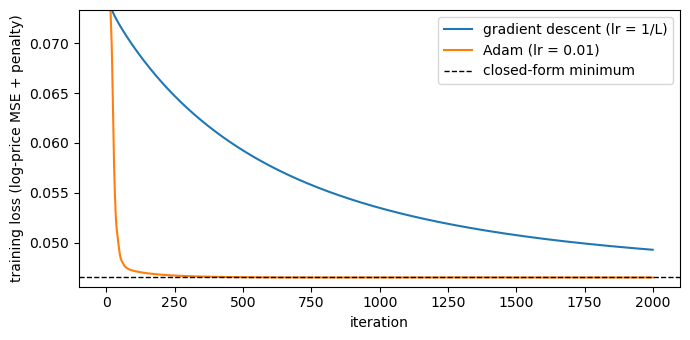

In [17]:
def ridge_loss(w, Xc, yc, alpha):
    r = Xc @ w - yc
    return float((r @ r + alpha * (w @ w)) / len(yc))

def ridge_grad(w, Xc, yc, alpha):
    return (2 / len(yc)) * (Xc.T @ (Xc @ w - yc) + alpha * w)

def train_gd(Xc, yc, alpha, steps):
    L = (2 / len(yc)) * (np.linalg.eigvalsh(Xc.T @ Xc).max() + alpha)   # largest curvature
    lr = 1.0 / L
    w = np.zeros(Xc.shape[1]); hist = []
    for _ in range(steps):
        w -= lr * ridge_grad(w, Xc, yc, alpha)
        hist.append(ridge_loss(w, Xc, yc, alpha))
    return w, hist, lr

def train_adam(Xc, yc, alpha, steps, lr=0.01, b1=0.9, b2=0.999, eps=1e-8):
    d = Xc.shape[1]
    w = np.zeros(d); m = np.zeros(d); v = np.zeros(d); hist = []
    for t in range(1, steps + 1):
        g = ridge_grad(w, Xc, yc, alpha)
        m = b1 * m + (1 - b1) * g                 # first moment (mean of gradients)
        v = b2 * v + (1 - b2) * g * g             # second moment (mean of squared gradients)
        m_hat = m / (1 - b1 ** t)                 # bias corrections for the zero start
        v_hat = v / (1 - b2 ** t)
        w -= lr * m_hat / (np.sqrt(v_hat) + eps)  # per-coordinate step
        hist.append(ridge_loss(w, Xc, yc, alpha))
    return w, hist

ALPHA_DEMO = 1.0
Xc = X_dense - X_dense.mean(axis=0)
yc = y_train - y_train.mean()
w_cf = ridge_closed_form(X_dense, y_train, ALPHA_DEMO)
loss_cf = ridge_loss(w_cf, Xc, yc, ALPHA_DEMO)

STEPS = 2000
w_gd, hist_gd, lr_gd = train_gd(Xc, yc, ALPHA_DEMO, STEPS)
w_adam, hist_adam = train_adam(Xc, yc, ALPHA_DEMO, STEPS, lr=0.01)

eig = np.linalg.eigvalsh(Xc.T @ Xc)
print(f"condition number of (X'X + alpha I): {(eig.max() + ALPHA_DEMO) / (max(eig.min(), 0) + ALPHA_DEMO):,.0f}")
print(f"gradient descent: lr = {lr_gd:.3f}, final loss = {hist_gd[-1]:.5f}, "
      f"max |w - w_closed_form| = {np.abs(w_gd - w_cf).max():.3f}")
print(f"Adam:             lr = 0.010, final loss = {hist_adam[-1]:.5f}, "
      f"max |w - w_closed_form| = {np.abs(w_adam - w_cf).max():.5f}")
print(f"closed form:      loss = {loss_cf:.5f}")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(hist_gd, label="gradient descent (lr = 1/L)")
ax.plot(hist_adam, label="Adam (lr = 0.01)")
ax.axhline(loss_cf, color="k", ls="--", lw=1, label="closed-form minimum")
ax.set_xlabel("iteration"); ax.set_ylabel("training loss (log-price MSE + penalty)")
ax.set_ylim(loss_cf * 0.98, hist_gd[20]); ax.legend(); plt.tight_layout(); plt.show()


**What the curves show.**

* Adam reaches the closed-form weights (difference below $10^{-4}$) in about 1,500 iterations. The loop and the formula agree, so the iterative training is doing the same job as `Ridge.fit`.
* Plain gradient descent, at the largest stable step size, is still far from the minimum after 2,000 iterations. The condition number of $X^\top X + \alpha I$ is about 15,000: the population and income columns have very large curvature, the indicator for a suburb with one training sale has curvature near $\alpha$. One global step size has to be small enough for the steep directions and is then useless in the flat ones.
* This is the reason Adam (per-coordinate scaling) is the default for the neural network later, and the reason tree models, which do not use gradient steps on weights at all, are not affected by feature scaling.


### 5.3 Choosing α on the validation set

Only the validation set (2021 H1) is used to pick $\alpha$. The test set is scored once, after the choice is made.


In [18]:
def fit_ridge(alpha: float, use_macro: bool = True, use_suburb: bool = True) -> Pipeline:
    return Pipeline([
        ("pre", make_preprocessor(use_macro, use_suburb)),
        ("ridge", Ridge(alpha=alpha)),
    ]).fit(train, y_train)

alphas = [0.01, 0.1, 1, 3, 10, 30, 100]
sweep = []
for a in alphas:
    m = fit_ridge(a)
    sweep.append({"alpha": a, **metrics(val["price"], np.exp(m.predict(val)))})
sweep = pd.DataFrame(sweep)
print(sweep.to_string(index=False))

best_alpha = float(sweep.sort_values(["PPE10 (%)", "MdAPE (%)"], ascending=[False, True]).iloc[0]["alpha"])
print("\nchosen alpha:", best_alpha)


 alpha  PPE10 (%)  MdAPE (%)  median bias (%)  RMSE log  RMSE AUD
  0.01       34.0       15.6              1.6     0.281    811473
  0.10       34.3       15.6              1.6     0.278    787544
  1.00       34.8       15.2              1.7     0.268    728722
  3.00       34.3       15.4              1.7     0.263    718843
 10.00       33.8       15.5              1.5     0.267    728792
 30.00       32.4       16.6              1.3     0.276    747470
100.00       31.7       17.3              1.2     0.285    765870

chosen alpha: 1.0


In [19]:
ridge_model = fit_ridge(best_alpha)

record("ridge (log price)", "validation", val["price"], np.exp(ridge_model.predict(val)))
record("ridge (log price)", "test",       test["price"], np.exp(ridge_model.predict(test)))
print(results_table("test").to_string(index=False))

# Which inputs carry the largest weights? (standardised features, so weights are comparable within a block)
feature_names = ridge_model.named_steps["pre"].get_feature_names_out()
coefs = pd.Series(ridge_model.named_steps["ridge"].coef_, index=feature_names)
print("\nlargest positive weights:")
print(coefs.sort_values(ascending=False).head(6).round(3).to_string())
print("\nlargest negative weights:")
print(coefs.sort_values().head(6).round(3).to_string())


                         model  PPE10 (%)  MdAPE (%)  median bias (%)  RMSE log  RMSE AUD
       baseline: global median       21.1       32.8            -32.5     0.632   1438877
       baseline: suburb median       10.7       34.7            -32.7     0.536   1183415
baseline: suburb x type median       12.3       33.0            -30.9     0.510   1151739
             ridge (log price)       33.6       15.9              8.7     0.258    721589

largest positive weights:
cat__suburb_Holroyd             1.021
cat__suburb_Blue Bay            0.698
cat__suburb_Darling Point       0.561
cat__suburb_Chippendale         0.527
cat__suburb_Telopea             0.475
cat__suburb_Chain Valley Bay    0.474

largest negative weights:
cat__suburb_Bensville         -0.459
cat__suburb_Empire Bay        -0.424
cat__suburb_Erina Heights     -0.401
cat__suburb_Alexandria        -0.382
cat__suburb_Erskineville      -0.355
cat__suburb_Wentworth Point   -0.354


### 5.4 Reading the result

* **The linear model clears the bar.** On the test set PPE10 rises from about 21% (best baseline) to about 34%, and MdAPE falls from about 33% to about 16%. Half of the sales are now priced within 16%.
* **The 30% under-pricing is gone, and has turned into over-pricing.** Median bias on test is about **+9%**, against about +2% on validation. `year`, `cash_rate` and `property_inflation_index` all sit outside their training range in 2021, and a linear model extends the 2016–2020 trend in a straight line. In 2021 H1 that extension was about right; by H2 the line runs ahead of the market. Extrapolation fixed the direction of the error but overshot.
* **α matters little.** Validation PPE10 moves within about 3 points across four orders of magnitude of α. The one-hot suburb block is doing most of the work, and the standardised numeric block is not badly conditioned.
* **The largest weights are all suburb indicators**, several of them (Holroyd, Blue Bay, Chain Valley Bay) suburbs with a handful of training sales. That is exactly the effect the L2 penalty is meant to limit; with α = 1 it still lets a one-sale suburb move the estimate by e^1.0 ≈ 2.7×. Section 8 tests how much the suburb block is worth by removing it (about 7 PPE10 points in the prototype run).
* **Limits of a linear fit.** One weight per feature means an extra bedroom adds the same log-price everywhere, and land size has the same value in Mosman and Windsor. The tree model in Section 6 removes that restriction.


## 6. Model 2: gradient-boosted trees (LightGBM)

### 6.1 Why a tree ensemble, and what it is

Ridge gives every feature one weight. An extra bedroom adds the same amount to log-price in Mosman and in Mount Druitt; land size is worth the same per log-m² everywhere. A decision tree splits the data into regions (for example *suburb in {…} and property_size > 600*) and fits a constant in each region, so it can express those interactions without anyone listing them.

**Hypothesis space.** $f(x) = \sum_{k=1}^{K} \nu \, t_k(x)$: a sum of $K$ small regression trees, each with at most `num_leaves` leaves, scaled by the learning rate $\nu$.

**Loss.** The same as Section 5, squared error on log price, $L = \frac{1}{n}\sum_i (f(x_i) - \log y_i)^2$, without the L2 term. Regularisation comes instead from the tree size, the minimum leaf size, the learning rate and early stopping.

**Training algorithm (gradient boosting).** Start from $f_0 = $ mean of $\log y$. At round $k$, compute the negative gradient of the loss at the current prediction, $r_i = \log y_i - f_{k-1}(x_i)$ (for squared error the negative gradient is just the residual), fit a small tree $t_k$ to the residuals, and set $f_k = f_{k-1} + \nu\, t_k$. Each tree is a gradient step in function space. Stop when the validation loss has not improved for 100 rounds.

**Encoding.** Trees compare a feature with a threshold, so standardising and log-transforming change nothing; the numeric columns go in raw. `type` and `suburb` are passed as LightGBM categorical features, which lets a split group suburbs directly instead of asking for 626 one-hot columns. The information given to the model is identical to Section 5.


In [20]:
import lightgbm as lgb
import warnings
# LightGBM >= 4.7 renamed eval_set; the old name still works everywhere, including older Colab versions.
warnings.filterwarnings("ignore", message=".*eval_set.*")

TREE_NUMERIC = ["num_bed", "num_bath", "num_parking", "property_size",
                "suburb_population", "suburb_median_income", "suburb_sqkm",
                "suburb_lat", "suburb_lng", "suburb_elevation", "km_from_cbd",
                "year", "month", "cash_rate", "property_inflation_index"]
TREE_CATEGORICAL = ["type", "suburb"]
CATEGORY_LEVELS = {c: sorted(train[c].unique()) for c in TREE_CATEGORICAL}   # fixed on train only

def tree_frame(df: pd.DataFrame, numeric=TREE_NUMERIC) -> pd.DataFrame:
    """Raw numerics plus pandas Categorical columns with training-set levels (unseen -> NaN)."""
    X = df[numeric + TREE_CATEGORICAL].copy()
    for c in TREE_CATEGORICAL:
        X[c] = pd.Categorical(X[c], categories=CATEGORY_LEVELS[c])
    return X

def fit_lgbm(num_leaves: int, learning_rate: float = 0.05, min_child_samples: int = 20,
             numeric=TREE_NUMERIC, y_tr=y_train, y_va=y_val, seed: int = SEED):
    model = lgb.LGBMRegressor(
        objective="regression",          # squared error on the (log) target
        n_estimators=3000,               # upper bound; early stopping picks the real K
        num_leaves=num_leaves,
        learning_rate=learning_rate,
        min_child_samples=min_child_samples,
        random_state=seed,
        verbose=-1,
    )
    model.fit(
        tree_frame(train, numeric), y_tr,
        eval_set=[(tree_frame(train, numeric), y_tr), (tree_frame(val, numeric), y_va)],
        eval_names=["train", "validation"],
        eval_metric="l2",
        callbacks=[lgb.early_stopping(100, verbose=False)],
    )
    return model

sweep_lgbm = []
for leaves in [7, 15, 31, 63]:
    m = fit_lgbm(num_leaves=leaves)
    sweep_lgbm.append({"num_leaves": leaves, "trees used": m.best_iteration_,
                       **metrics(val["price"], np.exp(m.predict(tree_frame(val))))})
sweep_lgbm = pd.DataFrame(sweep_lgbm)
print(sweep_lgbm.to_string(index=False))
best_leaves = int(sweep_lgbm.sort_values(["PPE10 (%)", "MdAPE (%)"], ascending=[False, True]).iloc[0]["num_leaves"])
print("\nchosen num_leaves:", best_leaves)


 num_leaves  trees used  PPE10 (%)  MdAPE (%)  median bias (%)  RMSE log  RMSE AUD
          7         901       33.3       16.3            -10.3     0.281    779404
         15         673       33.4       16.3             -9.9     0.280    773210
         31         191       31.7       15.8            -10.8     0.277    771228
         63         246       32.5       15.6            -11.3     0.279    788127

chosen num_leaves: 15


                         model  PPE10 (%)  MdAPE (%)  median bias (%)  RMSE log  RMSE AUD
       baseline: global median       21.1       32.8            -32.5     0.632   1438877
       baseline: suburb median       10.7       34.7            -32.7     0.536   1183415
baseline: suburb x type median       12.3       33.0            -30.9     0.510   1151739
             ridge (log price)       33.6       15.9              8.7     0.258    721589
          lightgbm (log price)       22.5       20.1            -18.2     0.320    849930


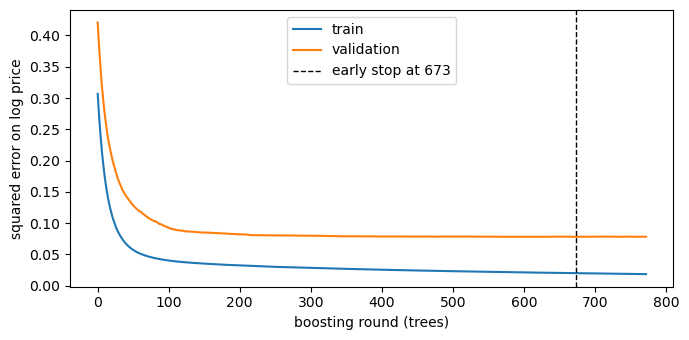

In [21]:
lgbm_model = fit_lgbm(num_leaves=best_leaves)

record("lightgbm (log price)", "validation", val["price"], np.exp(lgbm_model.predict(tree_frame(val))))
record("lightgbm (log price)", "test",       test["price"], np.exp(lgbm_model.predict(tree_frame(test))))
print(results_table("test").to_string(index=False))

# learning curve: training vs validation loss per boosting round
ev = lgbm_model.evals_result_
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(ev["train"]["l2"], label="train")
ax.plot(ev["validation"]["l2"], label="validation")
ax.axvline(lgbm_model.best_iteration_, color="k", ls="--", lw=1, label=f"early stop at {lgbm_model.best_iteration_}")
ax.set_xlabel("boosting round (trees)"); ax.set_ylabel("squared error on log price"); ax.legend()
plt.tight_layout(); plt.show()


### 6.2 The tree model is worse than the linear model on the 2021 test set. Why?

The table above is not what a "stronger model" is supposed to produce: PPE10 falls from about 34% (Ridge) to about 22%, and the median bias is about **−18%** where Ridge was +9%. Two checks locate the cause.

**Check 1: does the model react to 2021 at all?** Take the test rows and overwrite `year`, `cash_rate` and `property_inflation_index` with values from the end of 2020, the last the model saw in training. If the predictions do not change, the model is pricing 2021 as if it were 2020.


In [22]:
test_as_2020 = test.copy()
test_as_2020["year"] = 2020
test_as_2020["cash_rate"] = train["cash_rate"].min()                           # 0.10, already reached in 2020
test_as_2020["property_inflation_index"] = train["property_inflation_index"].max()   # 183.1, the last training value

pred_real = lgbm_model.predict(tree_frame(test))
pred_2020 = lgbm_model.predict(tree_frame(test_as_2020))
print("largest change in prediction when 2021 macro inputs are replaced by 2020 values:",
      f"{np.abs(pred_real - pred_2020).max():.4f}")

print("\ntraining range   year 2016–2020 | cash_rate 0.10–2.00 | index 150.9–183.1")
print("test range       year 2021–2022 | cash_rate 0.10–0.10 | index 183.1–220.1")


largest change in prediction when 2021 macro inputs are replaced by 2020 values: 0.0000

training range   year 2016–2020 | cash_rate 0.10–2.00 | index 150.9–183.1
test range       year 2021–2022 | cash_rate 0.10–0.10 | index 183.1–220.1


The change is **exactly zero**. A tree splits on thresholds learned from training data; every 2021 row falls on the "≥ 183.1" / "≥ 2020" side of every split, the same side as late-2020 sales. A tree ensemble **cannot extrapolate**: outside the training range its prediction is flat. Ridge, with a single weight per feature, extends the trend in a straight line and (over)shoots instead.

**Check 2: is the tree better when there is no extrapolation?** Fit both models on sales before July 2020 and score them on 2020 H2, a period whose macro values are inside the training range.


In [23]:
cut = "2020-07-01"
inner_train = train[train["date_sold"] < cut]
inner_hold = train[train["date_sold"] >= cut]

# Ridge on the inner split
ridge_inner = Pipeline([("pre", make_preprocessor()), ("ridge", Ridge(alpha=best_alpha))]).fit(
    inner_train, np.log(inner_train["price"].to_numpy()))

# LightGBM on the inner split (categories fixed on inner_train; same number of trees as the chosen model)
inner_levels = {c: sorted(inner_train[c].unique()) for c in TREE_CATEGORICAL}
def inner_frame(df):
    X = df[TREE_NUMERIC + TREE_CATEGORICAL].copy()
    for c in TREE_CATEGORICAL:
        X[c] = pd.Categorical(X[c], categories=inner_levels[c])
    return X
lgbm_inner = lgb.LGBMRegressor(objective="regression", n_estimators=lgbm_model.best_iteration_,
                               num_leaves=best_leaves, learning_rate=0.05, random_state=SEED, verbose=-1
                               ).fit(inner_frame(inner_train), np.log(inner_train["price"].to_numpy()))

inner = pd.DataFrame([
    {"model": "ridge",    "scored on": "2020 H2 (inside training range)", **metrics(inner_hold["price"], np.exp(ridge_inner.predict(inner_hold)))},
    {"model": "lightgbm", "scored on": "2020 H2 (inside training range)", **metrics(inner_hold["price"], np.exp(lgbm_inner.predict(inner_frame(inner_hold))))},
])
print(inner.to_string(index=False))


   model                       scored on  PPE10 (%)  MdAPE (%)  median bias (%)  RMSE log  RMSE AUD
   ridge 2020 H2 (inside training range)       37.1       14.5              1.6     0.277    780580
lightgbm 2020 H2 (inside training range)       43.7       12.0             -1.0     0.262    749205


### 6.3 What Section 6 establishes

* **Inside the training range the tree wins clearly**: on 2020 H2 LightGBM reaches about 43% PPE10 and 12% MdAPE against about 37% and 15% for Ridge, with almost no bias. The interactions it can express (suburb × size × type) are real.
* **Across the 2021 shift it loses**, because it cannot move its predictions past the last training value of `year` or `property_inflation_index`. The −18% test bias is, almost exactly, the 2021 price rise the model never saw.
* **The failure is in the inputs, not the trees.** The time trend is being asked of a model class that is flat outside its data. Section 8 moves the trend out of the model: predict the price *relative to the price index* and multiply the index back in. A quick run of that idea already gives about 39% PPE10 on test with bias near −4%, better than both models here.
* **Hyperparameters mattered little** on validation (PPE10 within about 2 points across 7–63 leaves; early stopping chose the number of trees). The design choice that mattered was what the target and the time features mean.


## 7. Model 3: a small neural network (PyTorch)

### 7.1 Why include it

Ridge extrapolates but cannot express interactions; the tree ensemble expresses interactions but cannot extrapolate. A multilayer perceptron with ReLU units is a **piecewise-linear** function: inside the data it can bend, outside the data it continues linearly. It is the natural third case to test. It also lets the training loop from Section 5.2b (forward pass, loss, gradient, Adam step) be shown on a model that actually needs it.

**Hypothesis space.** $f(x) = W_3\,\sigma\!\bigl(W_2\,\sigma(W_1 x + b_1) + b_2\bigr) + b_3$ with $\sigma = \mathrm{ReLU}$, layer widths 616 → 128 → 64 → 1. About 87,000 parameters, against 616 for Ridge.

**Loss.** Squared error on log price, as in Sections 5 and 6, plus a small L2 term through Adam's `weight_decay`.

**Training.** Mini-batch Adam (batch 256, lr $10^{-3}$), dropout 0.1 after each hidden layer, and **early stopping**: after every epoch the validation loss is computed, and the weights with the lowest validation loss are kept. Training stops after 30 epochs without improvement. The output bias is initialised to the mean log price so the first predictions are already in the right range.

**Inputs.** The Section 5 encoding (standardised numerics, one-hot type and suburb). Neural networks, like Ridge, are sensitive to feature scale, so the raw columns used for the trees would not work here.


In [24]:
import torch
import torch.nn as nn

torch.set_num_threads(max(1, os.cpu_count() // 2))

def to_tensor(df: pd.DataFrame, pre) -> torch.Tensor:
    X = pre.transform(df)
    X = X.toarray() if hasattr(X, "toarray") else X
    return torch.tensor(X, dtype=torch.float32)

pre_mlp = make_preprocessor().fit(train)
Xt_train, Xt_val, Xt_test = (to_tensor(d, pre_mlp) for d in (train, val, test))
yt_train = torch.tensor(y_train, dtype=torch.float32)
yt_val = torch.tensor(y_val, dtype=torch.float32)

def build_mlp(n_in: int, hidden=(128, 64), dropout: float = 0.1) -> nn.Sequential:
    layers, d = [], n_in
    for h in hidden:
        layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]
        d = h
    layers.append(nn.Linear(d, 1))
    net = nn.Sequential(*layers)
    with torch.no_grad():
        net[-1].bias.fill_(float(yt_train.mean()))     # start at the mean log price
    return net

def train_mlp(seed: int, hidden=(128, 64), lr: float = 1e-3, weight_decay: float = 1e-4,
              dropout: float = 0.1, batch_size: int = 256, max_epochs: int = 300, patience: int = 30):
    torch.manual_seed(seed)
    net = build_mlp(Xt_train.shape[1], hidden, dropout)
    opt = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=weight_decay)
    history, best = [], {"val_loss": float("inf"), "state": None, "epoch": -1}
    n = len(Xt_train)

    for epoch in range(max_epochs):
        net.train()
        for idx in torch.randperm(n).split(batch_size):
            opt.zero_grad()
            pred = net(Xt_train[idx]).squeeze(1)                 # forward pass
            loss = ((pred - yt_train[idx]) ** 2).mean()          # squared error on log price
            loss.backward()                                      # gradients by backpropagation
            opt.step()                                           # Adam update (Section 5.2b, per parameter)
        net.eval()
        with torch.no_grad():
            tr_loss = ((net(Xt_train).squeeze(1) - yt_train) ** 2).mean().item()
            va_loss = ((net(Xt_val).squeeze(1) - yt_val) ** 2).mean().item()
        history.append((tr_loss, va_loss))
        if va_loss < best["val_loss"]:
            best = {"val_loss": va_loss, "state": {k: v.clone() for k, v in net.state_dict().items()}, "epoch": epoch}
        elif epoch - best["epoch"] >= patience:
            break

    net.load_state_dict(best["state"]); net.eval()
    return net, pd.DataFrame(history, columns=["train", "validation"]), best["epoch"]

def predict_mlp(net, Xt) -> np.ndarray:
    with torch.no_grad():
        return np.exp(net(Xt).squeeze(1).numpy())

n_params = sum(p.numel() for p in build_mlp(Xt_train.shape[1]).parameters())
print(f"input width {Xt_train.shape[1]}, parameters {n_params:,}")


input width 616, parameters 87,297


### 7.2 Five seeds, not one

A network trained twice from different random initialisations gives two different models. One run is an anecdote. Five seeds give a mean and a spread, which is what the validation and test numbers below report. The model that is carried into the results table is the seed with the best **validation** PPE10; the test set does not take part in that choice.


In [25]:
SEEDS = [0, 1, 2, 3, 4]
mlp_runs = []
for sd in SEEDS:
    net, hist, best_epoch = train_mlp(seed=sd)
    mlp_runs.append({
        "seed": sd, "net": net, "history": hist, "best_epoch": best_epoch,
        "val": metrics(val["price"], predict_mlp(net, Xt_val)),
        "test": metrics(test["price"], predict_mlp(net, Xt_test)),
    })

seed_table = pd.DataFrame([
    {"seed": r["seed"], "best epoch": r["best_epoch"],
     "val PPE10": r["val"]["PPE10 (%)"], "val MdAPE": r["val"]["MdAPE (%)"], "val bias": r["val"]["median bias (%)"],
     "test PPE10": r["test"]["PPE10 (%)"], "test MdAPE": r["test"]["MdAPE (%)"], "test bias": r["test"]["median bias (%)"]}
    for r in mlp_runs])
print(seed_table.to_string(index=False))
print("\nmean ± std over seeds:")
print(seed_table.drop(columns=["seed", "best epoch"]).agg(["mean", "std"]).round(2).to_string())

best_run = max(mlp_runs, key=lambda r: (r["val"]["PPE10 (%)"], -r["val"]["MdAPE (%)"]))
mlp_model = best_run["net"]
print("\nseed carried forward (best validation PPE10):", best_run["seed"])

record("mlp (log price)", "validation", val["price"], predict_mlp(mlp_model, Xt_val))
record("mlp (log price)", "test",       test["price"], predict_mlp(mlp_model, Xt_test))
print("\n" + results_table("test").to_string(index=False))


 seed  best epoch  val PPE10  val MdAPE  val bias  test PPE10  test MdAPE  test bias
    0          12       34.5       15.2      -3.2        34.3        15.2        1.8
    1           6       35.9       14.8      -0.2        37.3        14.2        2.4
    2           6       36.4       14.3      -1.9        33.6        15.7        7.6
    3           5       35.3       14.7       0.1        29.4        18.3       12.7
    4           5       34.4       15.0       0.8        33.7        15.9        6.4

mean ± std over seeds:
      val PPE10  val MdAPE  val bias  test PPE10  test MdAPE  test bias
mean      35.30      14.80     -0.88       33.66       15.86       6.18
std        0.87       0.34      1.63        2.82        1.51       4.42

seed carried forward (best validation PPE10): 2

                         model  PPE10 (%)  MdAPE (%)  median bias (%)  RMSE log  RMSE AUD
       baseline: global median       21.1       32.8            -32.5     0.632   1438877
       baseline: sub

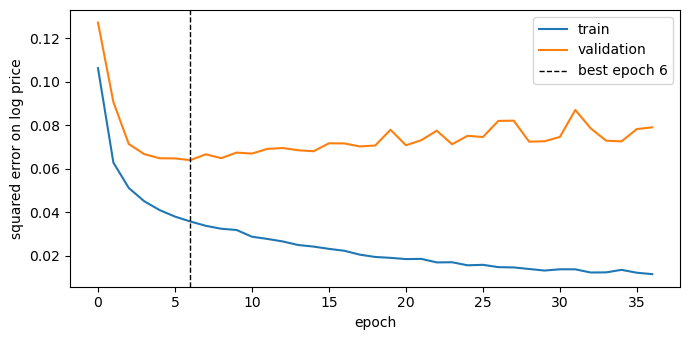

MLP: median change in log prediction when 2021 macro inputs are replaced by 2020 values: 0.234 (≈ 26% in price). LightGBM: 0.000.


In [26]:
# learning curve for the carried-forward seed, and the extrapolation check from Section 6
fig, ax = plt.subplots(figsize=(7, 3.5))
h = best_run["history"]
ax.plot(h["train"], label="train"); ax.plot(h["validation"], label="validation")
ax.axvline(best_run["best_epoch"], color="k", ls="--", lw=1, label=f"best epoch {best_run['best_epoch']}")
ax.set_xlabel("epoch"); ax.set_ylabel("squared error on log price"); ax.legend(); plt.tight_layout(); plt.show()

with torch.no_grad():
    p_real = mlp_model(Xt_test).squeeze(1).numpy()
    p_2020 = mlp_model(to_tensor(test_as_2020, pre_mlp)).squeeze(1).numpy()
shift = np.median(p_real - p_2020)
print(f"MLP: median change in log prediction when 2021 macro inputs are replaced by 2020 values: {shift:.3f} "
      f"(≈ {100 * (np.exp(shift) - 1):.0f}% in price). LightGBM: 0.000.")


### 7.3 What the network adds, and what it does not

* **On average it matches Ridge, not LightGBM-in-range.** Mean test PPE10 over five seeds is about 34% with MdAPE about 16%, the same level as the linear model. The ability to bend did not buy accuracy here: with 5,629 training rows and 616 mostly-sparse inputs, the network stops improving after fewer than 10 epochs and then overfits (validation loss turns up while training loss keeps falling).
* **It extrapolates, like Ridge.** Replacing the 2021 macro inputs by 2020 values moves its predictions by roughly a quarter of the price. ReLU networks are linear outside the data, so the trend continues; the trees stayed flat. This confirms that the Section 6 failure is a property of the tree model class.
* **It is the least stable of the three.** Validation PPE10 varies by about 1 point across seeds, test PPE10 by about 3 points and test bias by about 4 points. The same architecture, same data and same hyperparameters give a test bias between roughly +2% and +13% depending only on the random initialisation. A single-seed result for this model would be misleading, which is why the table reports the spread.
* **Cost.** About 87,000 parameters and a GPU-free minute of training for a result a 616-weight linear model equals. For this table size, the tree model's in-range advantage (Section 6.2) is the better use of complexity, once its extrapolation problem is handled.


## 8. Ablations: answering the research question

Sections 5–7 changed the **model** and kept everything else fixed. This section keeps the model fixed and changes one **design decision** at a time. Each experiment is a named row; the harness below trains LightGBM (and, where informative, Ridge) with a given feature list and a given target, and scores validation and test.

The research question from Section 2.1: *can a model fitted to 2016–2020 price the 2021 market, and do the macro inputs or an index-adjusted target reduce the error caused by the shift?*

| Experiment | What changes | Question it answers |
|---|---|---|
| **A** target scale | `price` vs `log(price)` | Is the log target actually better, or just conventional? |
| **B** trend inputs | drop `cash_rate`, `property_inflation_index`; then also `year`, `month` | Where does the model get its knowledge of the 2021 rise? |
| **C** index-adjusted target | predict $\log(\text{price}) - \log(\text{index})$, add the index back | Can the trend be taken *out* of the model so the trees do not have to extrapolate? |
| **C′** realistic index | same, but with the index published one quarter earlier | What does the fix cost when the current quarter's index is not yet known? |
| **D** suburb | drop the `suburb` categorical | How much is the suburb identity worth on top of the suburb-level numbers? |
| **E** split | random split instead of the time split | How much would the headline number be inflated by leakage? |

**The idea behind C.** The price index $I_t$ is a market-wide level. If a property's price is $y = I_t \cdot g(x)$ with $g$ depending only on the property, then $\log y - \log I_t = \log g(x)$ has no trend and every training year looks alike. The trees fit $g$; the index, which *is* published, supplies the level. The model no longer has to extrapolate anything.


In [27]:
PROPERTY_NUMERIC = ["num_bed", "num_bath", "num_parking", "property_size",
                    "suburb_population", "suburb_median_income", "suburb_sqkm",
                    "suburb_lat", "suburb_lng", "suburb_elevation", "km_from_cbd"]
TIME_FEATURES = ["year", "month"]
MACRO_FEATURES = ["cash_rate", "property_inflation_index"]

# C': the index value that was already available one quarter (91 days) before the sale.
index_by_date = sales.groupby("date_sold")["property_inflation_index"].median().sort_index()
def lagged_index(dates: pd.Series, lag_days: int = 91) -> np.ndarray:
    pos = index_by_date.index.searchsorted(dates - pd.Timedelta(days=lag_days), side="right") - 1
    return index_by_date.to_numpy()[np.clip(pos, 0, len(index_by_date) - 1)]
for part in (train, val, test):
    part["index_lag1q"] = lagged_index(part["date_sold"])
print("test period: same-quarter index / lagged index =", round(float((test["property_inflation_index"] / test["index_lag1q"]).mean()), 3))

ABLATIONS: list[dict] = []

def offsets(col):
    """log(index) per split, or zeros when no target adjustment is used."""
    if col is None:
        return [np.zeros(len(p)) for p in (train, val, test)]
    return [np.log(p[col].to_numpy()) for p in (train, val, test)]

def run_ablation(name: str, kind: str, numeric: list, categorical=TREE_CATEGORICAL,
                 log_target: bool = True, adjust_col: str | None = None):
    off_tr, off_va, off_te = offsets(adjust_col)
    if log_target:
        t_tr, t_va = y_train - off_tr, y_val - off_va
        back = lambda z, off: np.exp(z + off)
    else:
        t_tr, t_va = train["price"].to_numpy(), val["price"].to_numpy()
        back = lambda z, off: np.clip(z, 10_000, None)

    if kind == "lightgbm":
        m = lgb.LGBMRegressor(objective="regression", n_estimators=3000, num_leaves=best_leaves,
                              learning_rate=0.05, random_state=SEED, verbose=-1)
        levels = {c: CATEGORY_LEVELS[c] for c in categorical}
        def frame(df):
            X = df[numeric + categorical].copy()
            for c in categorical:
                X[c] = pd.Categorical(X[c], categories=levels[c])
            return X
        m.fit(frame(train), t_tr, eval_set=[(frame(val), t_va)], callbacks=[lgb.early_stopping(100, verbose=False)])
        pv, pt = m.predict(frame(val)), m.predict(frame(test))
    else:  # ridge on the Section 5 encoding
        num_std = [c for c in numeric if c != "property_size"]
        pre = ColumnTransformer([
            ("num", StandardScaler(), num_std),
            ("lognum", Pipeline([("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")), ("scale", StandardScaler())]), ["property_size"]),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)])
        m = Pipeline([("pre", pre), ("ridge", Ridge(alpha=best_alpha))]).fit(train, t_tr)
        pv, pt = m.predict(val), m.predict(test)

    row = {"experiment": name, "model": kind}
    row.update({f"val {k}": v for k, v in metrics(val["price"], back(pv, off_va)).items() if k in ("PPE10 (%)", "MdAPE (%)", "median bias (%)")})
    row.update({f"test {k}": v for k, v in metrics(test["price"], back(pt, off_te)).items() if k in ("PPE10 (%)", "MdAPE (%)", "median bias (%)")})
    ABLATIONS.append(row)
    return m

ALL = PROPERTY_NUMERIC + TIME_FEATURES + MACRO_FEATURES
for kind in ("lightgbm", "ridge"):
    run_ablation("ref: log price, all features", kind, ALL)
    run_ablation("A: raw price target", kind, ALL, log_target=False)
    run_ablation("B1: no macro features", kind, PROPERTY_NUMERIC + TIME_FEATURES)
    run_ablation("B2: no time, no macro", kind, PROPERTY_NUMERIC)
    run_ablation("C: index-adjusted target, no time inputs", kind, PROPERTY_NUMERIC, adjust_col="property_inflation_index")
    run_ablation("C': same, index lagged one quarter", kind, PROPERTY_NUMERIC, adjust_col="index_lag1q")
run_ablation("C + month as input", "lightgbm", PROPERTY_NUMERIC + ["month"], adjust_col="property_inflation_index")
run_ablation("D: C without suburb categorical", "lightgbm", PROPERTY_NUMERIC, categorical=["type"], adjust_col="property_inflation_index")
run_ablation("D: ref without suburb categorical", "ridge", ALL, categorical=["type"])

ablation_table = pd.DataFrame(ABLATIONS)
with pd.option_context("display.width", 220):
    print(ablation_table.to_string(index=False))


test period: same-quarter index / lagged index = 1.036
                              experiment    model  val PPE10 (%)  val MdAPE (%)  val median bias (%)  test PPE10 (%)  test MdAPE (%)  test median bias (%)
            ref: log price, all features lightgbm           33.4           16.3                 -9.9            22.5            20.1                 -18.2
                     A: raw price target lightgbm           30.1           16.5                 -6.5            24.0            19.9                 -15.9
                   B1: no macro features lightgbm           24.5           19.6                -17.3            19.4            22.3                 -21.2
                   B2: no time, no macro lightgbm           22.9           20.0                -18.6            12.2            27.3                 -26.7
C: index-adjusted target, no time inputs lightgbm           37.3           14.1                 -3.7            37.7            13.5                  -4.6
      C': same,

In [28]:
# E: the same C-model, but trained and scored on a RANDOM split of the same sizes.
shuffled = sales.sample(frac=1, random_state=SEED)
n_tr, n_va = len(train), len(val)
r_train, r_val, r_test = shuffled.iloc[:n_tr], shuffled.iloc[n_tr:n_tr + n_va], shuffled.iloc[n_tr + n_va:]
r_levels = {c: sorted(r_train[c].unique()) for c in TREE_CATEGORICAL}
def r_frame(df):
    X = df[PROPERTY_NUMERIC + TREE_CATEGORICAL].copy()
    for c in TREE_CATEGORICAL:
        X[c] = pd.Categorical(X[c], categories=r_levels[c])
    return X
adj = lambda d: np.log(d["price"].to_numpy()) - np.log(d["property_inflation_index"].to_numpy())
m_rand = lgb.LGBMRegressor(objective="regression", n_estimators=3000, num_leaves=best_leaves, learning_rate=0.05,
                           random_state=SEED, verbose=-1)
m_rand.fit(r_frame(r_train), adj(r_train), eval_set=[(r_frame(r_val), adj(r_val))], callbacks=[lgb.early_stopping(100, verbose=False)])
rand_scores = metrics(r_test["price"], np.exp(m_rand.predict(r_frame(r_test)) + np.log(r_test["property_inflation_index"].to_numpy())))
time_scores = ablation_table.loc[(ablation_table["experiment"] == "C: index-adjusted target, no time inputs") & (ablation_table["model"] == "lightgbm")].iloc[0]
print(pd.DataFrame([
    {"split": "time (used)",      "test PPE10 (%)": time_scores["test PPE10 (%)"], "test MdAPE (%)": time_scores["test MdAPE (%)"], "test bias (%)": time_scores["test median bias (%)"]},
    {"split": "random (not used)", "test PPE10 (%)": rand_scores["PPE10 (%)"],   "test MdAPE (%)": rand_scores["MdAPE (%)"],   "test bias (%)": rand_scores["median bias (%)"]},
]).to_string(index=False))


            split  test PPE10 (%)  test MdAPE (%)  test bias (%)
      time (used)            37.7            13.5           -4.6
random (not used)            42.3            12.1            1.6


### 8.1 Reading the table

* **A — log target.** On validation the log target beats the raw-price target for both models (Ridge 34.8 vs 28.2 PPE10; LightGBM 33.4 vs 30.1). Squared error on raw AUD spends its effort on the expensive sales; squared error on log price treats a 10% miss the same everywhere, which is what the metric asks for.
* **B — the trend lives in the macro columns.** Remove `cash_rate` and `property_inflation_index` and both models fall to about 19–20% PPE10 with bias about −21%. Remove `year` and `month` as well and bias reaches −27%: that is the full 2021 rise, unseen. The macro columns are how any model here knows that prices moved. For the trees they help only up to the last training value (Section 6.2); for Ridge they are extrapolated.
* **C — moving the trend into the target fixes the tree model.** With $\log(\text{price}/\text{index})$ as target and no time inputs, LightGBM reaches about **37–38% PPE10, 13.5% MdAPE, bias about −4 to −5%** on test, from 22.5% / 20.1% / −18%. Ridge with the same target reaches about 37% as well. The fix is in the target, not the model class. The residual −4% says the index understates how much this segment of the market rose in 2021 H2.
* **C′ — a published index is enough.** Using the index from one quarter earlier, which is what a valuer would have on the day, costs about 1–2 PPE10 points and adds about 2 points of under-pricing. Deployment is feasible without knowing the current quarter.
* **D — suburb identity is worth a lot to Ridge and nothing to the trees.** Without the one-hot suburb block Ridge drops 7 points. LightGBM on the adjusted target loses nothing when the `suburb` categorical is removed (validation PPE10 is actually highest, about 39%), because `suburb_lat`, `suburb_lng`, `km_from_cbd` and `suburb_median_income` already locate the property and trees can carve regions out of them. This also removes the 148 unseen-suburb rows as a special case.
* **E — the random split would have inflated the headline by about 5 points** (about 42% vs 37–38% PPE10) and hidden the bias entirely.

### 8.2 Final model

Chosen on **validation** PPE10: LightGBM, target $\log(\text{price}) - \log(\text{index})$, property-level numerics plus suburb-level numerics, `type` categorical, no `suburb` categorical, no time inputs (experiment D). It is retrained below and entered in the main results table. Its realistic deployment score is the C′ row (index lagged one quarter).


In [29]:
final_numeric = PROPERTY_NUMERIC
final_categorical = ["type"]
log_idx_train, log_idx_val, log_idx_test = (np.log(p["property_inflation_index"].to_numpy()) for p in (train, val, test))

def final_frame(df):
    X = df[final_numeric + final_categorical].copy()
    X["type"] = pd.Categorical(X["type"], categories=CATEGORY_LEVELS["type"])
    return X

final_model = lgb.LGBMRegressor(objective="regression", n_estimators=3000, num_leaves=best_leaves,
                                learning_rate=0.05, random_state=SEED, verbose=-1)
final_model.fit(final_frame(train), y_train - log_idx_train,
                eval_set=[(final_frame(val), y_val - log_idx_val)],
                callbacks=[lgb.early_stopping(100, verbose=False)])
print("trees used:", final_model.best_iteration_)

def predict_final(df, log_idx):
    return np.exp(final_model.predict(final_frame(df)) + log_idx)

record("final: lightgbm, index-adjusted target", "validation", val["price"], predict_final(val, log_idx_val))
record("final: lightgbm, index-adjusted target", "test",       test["price"], predict_final(test, log_idx_test))
record("final, index lagged 1 quarter (deployment)", "test", test["price"],
       np.exp(final_model.predict(final_frame(test)) + np.log(test["index_lag1q"].to_numpy())))
print(results_table("test").to_string(index=False))


trees used: 620
                                     model  PPE10 (%)  MdAPE (%)  median bias (%)  RMSE log  RMSE AUD
                   baseline: global median       21.1       32.8            -32.5     0.632   1438877
                   baseline: suburb median       10.7       34.7            -32.7     0.536   1183415
            baseline: suburb x type median       12.3       33.0            -30.9     0.510   1151739
                         ridge (log price)       33.6       15.9              8.7     0.258    721589
                      lightgbm (log price)       22.5       20.1            -18.2     0.320    849930
                           mlp (log price)       33.6       15.7              7.6     0.249    729901
    final: lightgbm, index-adjusted target       37.9       13.4             -4.7     0.244    717937
final, index lagged 1 quarter (deployment)       35.7       14.5             -7.9     0.258    743714


### 8.3 Answer to the research question

A model fitted to 2016–2020 sales **cannot** price the 2021 market if the market level has to come from inside the model: trees stay flat at the last training value (−18% bias) and linear models extrapolate past it (+9%). It **can** if the level is supplied by a published price index and the model is asked only for the property's value *relative to the market*: about 38% of test sales within 10%, median error about 13%, bias about −4%, against 21% / 33% / −32% for the best rule-based baseline. With the index one quarter stale, as it would be on the day, the result is about 36% / 14.5% / −8%.


## 9. Training loss versus the task objective

### 9.1 The ideal comparison and why it is not the training loss

The task (Section 2) wants an estimate close to the sale price **in relative terms**, and the industry way of saying "close" is *within 10%*. The ideal comparison between a prediction and its label is therefore the 0/1 quantity

$$
\mathbb{1}\bigl[\,|\hat y - y| / y \le 0.10\,\bigr],
$$

averaged over sales: that is PPE10. It is used in this project at the **validation** stage (choosing α, `num_leaves`, the MLP seed, the final configuration) and at the **test** stage. It is **not** used for training, for two reasons:

1. It has zero gradient almost everywhere. A model that misses by 11% and one that misses by 60% get the same score, so no optimiser can move toward the boundary.
2. It ignores the size of a miss once it is over 10%. A valuer that is 60% wrong is worse than one that is 11% wrong, and the loss should say so.

So training uses **squared error on log price**, $(\log\hat y - \log y)^2$. It is smooth, convex in the prediction, and for small errors $\log\hat y - \log y \approx (\hat y - y)/y$, so it is approximately a squared *relative* error: the same direction as PPE10, without the flat regions.

### 9.2 Where the two disagree

**The loss is dominated by sales the metric does not care about.** The cell below sorts test sales by their squared log error under the final model.


In [30]:
y_te = test["price"].to_numpy()
p_final = predict_final(test, log_idx_test)
sq_log_err = (np.log(p_final) - np.log(y_te)) ** 2
ape_final = np.abs(p_final - y_te) / y_te

order = np.argsort(-sq_log_err)
top = int(0.05 * len(order))
print(f"worst 5% of test sales by squared log error: {100 * sq_log_err[order[:top]].sum() / sq_log_err.sum():.1f}% of the total loss, "
      f"{int((ape_final[order[:top]] <= 0.10).sum())} of them inside 10%")
print(f"share of test sales missed by more than 30%: {100 * (ape_final > 0.30).mean():.1f}%; by more than 50%: {100 * (ape_final > 0.50).mean():.1f}%")

# Does the choice of loss change the metric? Same final configuration, four LightGBM objectives.
LOSSES = {
    "L2 (squared error)": {"objective": "regression"},
    "L1 (absolute error)": {"objective": "regression_l1"},
    "Huber": {"objective": "huber", "alpha": 0.9},
    "Fair": {"objective": "fair"},
}
loss_rows = []
for name, params in LOSSES.items():
    m = lgb.LGBMRegressor(n_estimators=3000, num_leaves=best_leaves, learning_rate=0.05, random_state=SEED, verbose=-1, **params)
    m.fit(final_frame(train), y_train - log_idx_train, eval_set=[(final_frame(val), y_val - log_idx_val)],
          callbacks=[lgb.early_stopping(100, verbose=False)])
    pt = np.exp(m.predict(final_frame(test)) + log_idx_test)
    loss_rows.append({"training loss": name, "trees": m.best_iteration_, **metrics(test["price"], pt)})
print("\n" + pd.DataFrame(loss_rows).to_string(index=False))


worst 5% of test sales by squared log error: 41.8% of the total loss, 0 of them inside 10%
share of test sales missed by more than 30%: 15.6%; by more than 50%: 3.8%

      training loss  trees  PPE10 (%)  MdAPE (%)  median bias (%)  RMSE log  RMSE AUD
 L2 (squared error)    620       37.9       13.4             -4.7     0.244    717937
L1 (absolute error)    559       37.8       13.3             -5.9     0.254    759895
              Huber    423       37.3       13.5             -4.7     0.245    720618
               Fair    473       38.2       13.3             -4.7     0.246    724521


Two things follow.

* **About 42% of the training-style loss on the test set comes from 5% of the sales, and none of those sales count toward PPE10.** The squared loss spends most of its attention on the tail (about 16% of sales are missed by more than 30%), while the metric only watches the boundary at 10%. Minimising the loss further would mostly mean fixing tail cases the metric ignores.
* **Changing the loss changes PPE10 by less than one point** (L2 37.9%, L1 37.8%, Huber 37.3%, Fair 38.2%). L1 targets the conditional median instead of the mean, which shows up as a slightly lower MdAPE and a slightly more negative bias, but the ranking by RMSE-log (L2 best) and by PPE10 (Fair best) is not the same. The loss is a proxy; small differences in the proxy do not transfer to the objective. This is the reason model selection in this notebook was done on PPE10 and MdAPE, never on the training loss.

### 9.3 A second objective: the lender's asymmetric cost

For a buyer, over- and under-pricing are equally bad. For a **lender**, they are not: an over-valued property means a loan larger than the security. The point estimate above over-values about 41% of test sales and over-values by more than 10% about 24% of them. Squared error cannot fix this: it is symmetric by construction.

**Quantile regression** replaces the squared error by the *pinball loss*

$$
\ell_\tau(y, \hat q) = \begin{cases} \tau\,(y - \hat q) & y \ge \hat q \\ (1-\tau)\,(\hat q - y) & y < \hat q \end{cases}
$$

whose minimiser is the $\tau$-quantile of $y$ given $x$. Training the same trees with $\tau = 0.1, 0.25, 0.5, 0.75, 0.9$ gives a price **interval** and, for the lender, a deliberately conservative estimate.


 tau  share of test prices below estimate  pinball loss (log scale)
0.10                                0.109                    0.0365
0.25                                0.220                    0.0660
0.50                                0.379                    0.0920
0.75                                0.582                    0.0813
0.90                                0.809                    0.0513

coverage of the [q10, q90] interval: 70.0% (nominal 80%)
median interval width (q90 - q10) / price: 41.8%

      estimate used  over-valued (%)  over-valued by >10% (%)  under-valued by >10% (%)  PPE10 (%)
point estimate (L2)             40.7                     23.6                      38.5       37.9
                q50             37.9                     21.6                      40.6       37.8
                q25             22.0                      9.7                      57.7       32.6
                q10             10.9                      4.1                      74.4 

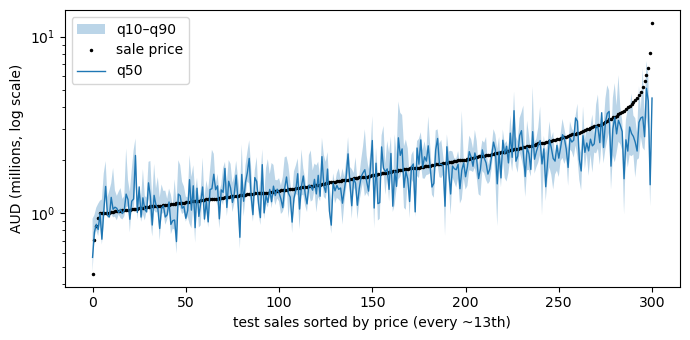

In [31]:
def pinball(y, q, tau):
    d = y - q
    return float(np.mean(np.where(d >= 0, tau * d, (tau - 1) * d)))

TAUS = [0.10, 0.25, 0.50, 0.75, 0.90]
quantile_pred = {}
quantile_models = {}
for tau in TAUS:
    mq = lgb.LGBMRegressor(objective="quantile", alpha=tau, n_estimators=3000, num_leaves=best_leaves,
                           learning_rate=0.05, random_state=SEED, verbose=-1)
    mq.fit(final_frame(train), y_train - log_idx_train, eval_set=[(final_frame(val), y_val - log_idx_val)],
           callbacks=[lgb.early_stopping(100, verbose=False)])
    quantile_models[tau] = mq
    quantile_pred[tau] = np.exp(mq.predict(final_frame(test)) + log_idx_test)

calib = pd.DataFrame([{
    "tau": tau,
    "share of test prices below estimate": round(float((y_te < quantile_pred[tau]).mean()), 3),
    "pinball loss (log scale)": round(pinball(np.log(y_te), np.log(quantile_pred[tau]), tau), 4),
} for tau in TAUS])
print(calib.to_string(index=False))
print(f"\ncoverage of the [q10, q90] interval: {100 * ((y_te >= quantile_pred[0.10]) & (y_te <= quantile_pred[0.90])).mean():.1f}% (nominal 80%)")
print(f"median interval width (q90 - q10) / price: {100 * np.median((quantile_pred[0.90] - quantile_pred[0.10]) / y_te):.1f}%")

lender = pd.DataFrame([{
    "estimate used": name,
    "over-valued (%)": round(100 * float((pred > y_te).mean()), 1),
    "over-valued by >10% (%)": round(100 * float((pred > 1.10 * y_te).mean()), 1),
    "under-valued by >10% (%)": round(100 * float((pred < 0.90 * y_te).mean()), 1),
    "PPE10 (%)": round(100 * float((np.abs(pred - y_te) / y_te <= 0.10).mean()), 1),
} for name, pred in [("point estimate (L2)", p_final), ("q50", quantile_pred[0.50]),
                     ("q25", quantile_pred[0.25]), ("q10", quantile_pred[0.10])]])
print("\n" + lender.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 3.5))
sample = np.argsort(y_te)[:: max(1, len(y_te) // 300)]
ax.fill_between(range(len(sample)), quantile_pred[0.10][sample] / 1e6, quantile_pred[0.90][sample] / 1e6, alpha=0.3, label="q10–q90")
ax.plot(y_te[sample] / 1e6, "k.", ms=3, label="sale price")
ax.plot(quantile_pred[0.50][sample] / 1e6, lw=1, label="q50")
ax.set_yscale("log"); ax.set_ylabel("AUD (millions, log scale)"); ax.set_xlabel("test sales sorted by price (every ~13th)")
ax.legend(); plt.tight_layout(); plt.show()


### 9.4 What the quantiles show, and what to monitor

* **The interval is too narrow on the high side.** Only about 81% of test prices fall below the q90 estimate and only about 38% below the q50, so the [q10, q90] band covers about 70% of sales instead of 80%. Every quantile is shifted down by the same few percent as the point estimate: the index under-states the 2021 H2 rise, and quantile regression inherits that bias. Calibration under market shift is a property of the *level*, not of the loss.
* **The lender's trade-off is explicit.** Using q25 instead of the point estimate cuts "over-valued by more than 10%" from about 24% to about 10% of sales; q10 cuts it to about 4%. The price is paid in PPE10 (38% → 33% → 22%) and in under-valuation. Which quantile to use is a business decision the model makes visible rather than hides.
* **Quantile crossings exist.** A few dozen test rows have q10 > q50 or q50 > q90 because each quantile is a separate model. A deployed version would sort the quantiles per property or fit them jointly.

**Monitoring and mitigation.** The mismatch between loss and objective is tolerable during training because the loss is smooth and the objective is not; it is *not* tolerable at selection or in production. Concretely: (1) select models on PPE10 / MdAPE, never on the loss (done here); (2) track **median bias by month** in production, since every failure mode seen in this notebook showed up first as bias, not as accuracy; (3) re-estimate the index adjustment as soon as a new quarter is published; (4) for lending, report a quantile, not the mean.


## 10. Error analysis, limitations and conclusion

### 10.1 Where the final model is right and where it is wrong

Aggregate numbers hide structure. The final model's test errors, cut four ways:


In [32]:
ea = test.copy()
ea["pred"] = p_final
ea["ape"] = ape_final
ea["rel"] = (p_final - y_te) / y_te

def by_group(key, bins=None, labels=None):
    g = pd.cut(ea[key], bins=bins, labels=labels) if bins is not None else ea[key]
    return (ea.groupby(g, observed=True)
              .agg(n=("price", "size"),
                   **{"PPE10 (%)": ("ape", lambda a: round(100 * float((a <= 0.10).mean()), 1)),
                      "MdAPE (%)": ("ape", lambda a: round(100 * float(a.median()), 1)),
                      "median bias (%)": ("rel", lambda r: round(100 * float(r.median()), 1))}))

print("by sale price"); print(by_group("price", [0, 8e5, 1.2e6, 2e6, 4e6, 1e9], ["<0.8M", "0.8–1.2M", "1.2–2M", "2–4M", ">4M"]).to_string()); print()
print("by distance from CBD"); print(by_group("km_from_cbd", [0, 10, 25, 45, 100], ["<10 km", "10–25 km", "25–45 km", ">45 km"]).to_string()); print()
ea["type_group"] = ea["type"].where(ea["type"].isin(["House", "Apartment / Unit / Flat", "Townhouse"]), "other")
print("by property type"); print(by_group("type_group").to_string()); print()
ea["suburb_seen"] = np.where(ea["suburb"].isin(train["suburb"]), "suburb in training", "suburb not in training")
print("by whether the suburb had training sales"); print(by_group("suburb_seen").to_string()); print()

print("five largest relative misses")
print(ea.nlargest(5, "ape")[["price", "pred", "suburb", "type", "num_bed", "num_bath", "property_size", "km_from_cbd"]].round(0).to_string(index=False))

gain = pd.Series(final_model.booster_.feature_importance("gain"), index=final_model.booster_.feature_name())
print("\nshare of split gain by feature (%)")
print((100 * gain / gain.sum()).sort_values(ascending=False).round(1).to_string())


by sale price
             n  PPE10 (%)  MdAPE (%)  median bias (%)
price                                                
<0.8M       23       26.1       14.9             12.5
0.8–1.2M   824       46.2       10.7              2.0
1.2–2M    1736       41.2       12.5             -1.5
2–4M      1152       31.0       15.7            -11.9
>4M        172       11.0       31.9            -31.7

by distance from CBD
                n  PPE10 (%)  MdAPE (%)  median bias (%)
km_from_cbd                                             
<10 km        709       36.0       14.3             -1.1
10–25 km     1634       39.0       13.1             -2.8
25–45 km      855       43.0       11.9             -5.2
>45 km        709       30.9       15.7            -11.5

by property type
                            n  PPE10 (%)  MdAPE (%)  median bias (%)
type_group                                                          
Apartment / Unit / Flat   200       29.0       18.3              6.6
House              

**Reading the cuts.**

* **The model is a mid-market model.** Between 0.8 M and 2 M AUD, where about two thirds of test sales sit, PPE10 is 41–46% and bias within ±2%. Above 4 M it collapses to about 11% PPE10 with bias about **−32%**: the top end rose far more than the city-wide index in 2021 H2, and a single index cannot carry that. The same shows at the fringe: sales more than 45 km out are under-priced by about 12%.
* **Apartments are over-priced (+7%) while houses are under-priced (−5%).** The index is dominated by houses; apartment prices in 2021 did not rise as fast. One level for the whole market is the model's main structural weakness.
* **Unseen suburbs are no longer a weak spot.** The 148 test sales in suburbs with no training data score as well as the rest (about 40% PPE10), because the final model never used the suburb name, only its coordinates and census figures.
* **The largest misses are data problems.** The five worst cases are "houses" with 7–10 bedrooms on ordinary blocks, priced by the model as mansions and sold as ordinary houses (or sold as sites). They passed the ≤10-bedroom rule of Section 2. A stricter rule on bedrooms per square metre would remove them.
* **Distance to the CBD carries a third of all split gain**, then bathrooms, land size and longitude. Suburb coordinates and income together carry more than the suburb name did for Ridge.

### 10.2 Final results

Test period: 3,907 sales, July 2021 – January 2022. Every model was trained on sales before 2021 and configured on the first half of 2021.


In [33]:
final_table = results_table("test").copy()
print(final_table.to_string(index=False))

# Two headline comparisons for the report / slides
best_baseline = final_table[final_table["model"].str.startswith("baseline")].sort_values("PPE10 (%)", ascending=False).iloc[0]
final_row = final_table[final_table["model"] == "final: lightgbm, index-adjusted target"].iloc[0]
deploy_row = final_table[final_table["model"] == "final, index lagged 1 quarter (deployment)"].iloc[0]
print(f"\nbest rule-based baseline : PPE10 {best_baseline['PPE10 (%)']}%, MdAPE {best_baseline['MdAPE (%)']}%, bias {best_baseline['median bias (%)']}%")
print(f"final model              : PPE10 {final_row['PPE10 (%)']}%, MdAPE {final_row['MdAPE (%)']}%, bias {final_row['median bias (%)']}%")
print(f"final model, deployable  : PPE10 {deploy_row['PPE10 (%)']}%, MdAPE {deploy_row['MdAPE (%)']}%, bias {deploy_row['median bias (%)']}%")


                                     model  PPE10 (%)  MdAPE (%)  median bias (%)  RMSE log  RMSE AUD
                   baseline: global median       21.1       32.8            -32.5     0.632   1438877
                   baseline: suburb median       10.7       34.7            -32.7     0.536   1183415
            baseline: suburb x type median       12.3       33.0            -30.9     0.510   1151739
                         ridge (log price)       33.6       15.9              8.7     0.258    721589
                      lightgbm (log price)       22.5       20.1            -18.2     0.320    849930
                           mlp (log price)       33.6       15.7              7.6     0.249    729901
    final: lightgbm, index-adjusted target       37.9       13.4             -4.7     0.244    717937
final, index lagged 1 quarter (deployment)       35.7       14.5             -7.9     0.258    743714

best rule-based baseline : PPE10 21.1%, MdAPE 32.8%, bias -32.5%
final model     

**How sure are these numbers?** A single test set gives a single PPE10. Resampling the 3,907 test sales with replacement 2,000 times gives a 95% interval for each metric, and for the *difference* between the final model and the best baseline. (The final LightGBM is deterministic for a fixed seed and has no bagging, so seed-to-seed variance is not the relevant uncertainty here; sampling variance of the test set is.)


In [34]:
rng = np.random.default_rng(SEED)
B = 2000
n_te = len(y_te)
p_base = baseline_global(train, test)

def boot_metric(pred, fn):
    vals = np.empty(B)
    for b in range(B):
        idx = rng.integers(0, n_te, n_te)
        vals[b] = fn(y_te[idx], pred[idx])
    return np.percentile(vals, [2.5, 97.5])

ppe10 = lambda y, p: 100 * np.mean(np.abs(p - y) / y <= 0.10)
mdape = lambda y, p: 100 * np.median(np.abs(p - y) / y)

ci = pd.DataFrame([
    {"model": "baseline: global median", "PPE10 95% CI": np.round(boot_metric(p_base, ppe10), 1),  "MdAPE 95% CI": np.round(boot_metric(p_base, mdape), 1)},
    {"model": "final model",             "PPE10 95% CI": np.round(boot_metric(p_final, ppe10), 1), "MdAPE 95% CI": np.round(boot_metric(p_final, mdape), 1)},
])
print(ci.to_string(index=False))

diff = np.empty(B)
for b in range(B):
    idx = rng.integers(0, n_te, n_te)
    diff[b] = ppe10(y_te[idx], p_final[idx]) - ppe10(y_te[idx], p_base[idx])
lo, hi = np.percentile(diff, [2.5, 97.5])
print(f"\nPPE10 gain of the final model over the best baseline: {ppe10(y_te, p_final) - ppe10(y_te, p_base):.1f} points, 95% CI [{lo:.1f}, {hi:.1f}]")


                  model PPE10 95% CI MdAPE 95% CI
baseline: global median [19.9, 22.4] [31.5, 34.7]
            final model [36.4, 39.4] [13.0, 13.9]

PPE10 gain of the final model over the best baseline: 16.7 points, 95% CI [14.9, 18.6]


### 10.3 Limitations

1. **One index for one city.** The adjustment uses a single market-wide series. The error analysis shows the premium segment (>4 M), the outer ring and apartments each moved differently from that series in 2021. Segment-specific indexes, or a learned time effect per segment, would be the first structural change.
2. **Location is suburb-level.** Coordinates are suburb centroids. Two houses in the same suburb, one on a main road and one on the water, are the same point to this model.
3. **Two days of the market.** The data are 2016–2022 and the shift tested is a rising one. Whether the index adjustment holds in a falling market (2022 onward) is untested; the sign of the bias could flip.
4. **The index may not be what it seems.** The provenance of `property_inflation_index` (which publisher, which dwelling types) was not verified. The lagged-index experiment covers the timing risk, not the definition risk.
5. **Data quality at the top.** The largest errors are implausible bedroom counts that survived cleaning. Cleaning thresholds were set by inspection, not by a published standard.
6. **No repeated-sales control.** The same property may appear in both training and test if it sold twice; there is no property identifier to check.

### 10.4 Future work, in order of expected value

1. Replace the single index by **per-segment levels** (house / unit, price band, distance ring), estimated from recent sales and refreshed monthly.
2. Fit the quantiles **jointly** (monotone constraints or a single multi-output model) to remove crossings, and **recalibrate** them on the most recent quarter before use.
3. Add **repeat-sales** detection and a bedrooms-per-m² cleaning rule.
4. Test the pipeline on a **falling** period once data after 2022 are available.

### 10.5 Conclusion

* **Task.** Estimate the sale price of one Greater Sydney dwelling from its attributes, judged by the share of estimates within 10% of the sale price, on sales that happened *after* the training period.
* **Finding.** The dominant error is not the model's inability to value a house; it is the market level. Rule-based baselines under-price the 2021 test period by about 32%. Tree models cannot extrapolate the level (−18%); linear and neural models extrapolate it too far (+8 to +9%). Moving the level out of the model — predicting the price *relative to a published index* — lifts LightGBM from 22.5% to about 38% PPE10 and Ridge from 34% to 37%, with bias about −5%. The remaining bias is segment-specific and points to per-segment levels as the next step.
* **Method.** All choices (α, tree size, MLP seed, final configuration) were made on a validation period that precedes the test period; a random split would have reported about 5 points more and hidden the bias. The training loss (squared log error) and the objective (PPE10) were kept distinct: the loss for optimisation, the objective for every decision.


## 11. Deployment: one function for one property

Section 2.1 specified the deployment interface in words. This section is that interface as code. `estimate_price()` takes the attributes a valuer would have on the day, checks them against the input specification of Section 2.3, fills in the suburb-level figures from a lookup table of static suburb attributes (census figures and coordinates, which do not depend on prices), applies the final model and the quantile models, and returns a price with an interval.

What the caller supplies: bedrooms, bathrooms, parking, land size, type, suburb, and the latest **published** price index (default: the last value in the data). What the caller does not supply: coordinates, census figures or the model's internals.


In [35]:
SUBURB_TABLE = (sales.groupby("suburb")[["suburb_population", "suburb_median_income", "suburb_sqkm",
                                          "suburb_lat", "suburb_lng", "suburb_elevation", "km_from_cbd"]]
                      .first())
LATEST_INDEX = float(sales.sort_values("date_sold")["property_inflation_index"].iloc[-1])

def estimate_price(num_bed: int, num_bath: int, num_parking: int, property_size: float,
                   type: str, suburb: str, price_index: float = LATEST_INDEX) -> dict:
    """Estimate the sale price (AUD) of one Greater Sydney dwelling.

    Returns the point estimate, a q10–q90 interval, and a conservative (q25) value for lending.
    Raises ValueError when the input is outside the specification of Section 2.3.
    """
    # --- input validation against the task specification --------------------------------
    for name, value, (lo, hi) in [("num_bed", num_bed, RULES["num_bed"]), ("num_bath", num_bath, RULES["num_bath"]),
                                  ("num_parking", num_parking, RULES["num_parking"]), ("property_size", property_size, RULES["property_size"])]:
        if not (lo <= value <= hi):
            raise ValueError(f"{name}={value} is outside the supported range [{lo}, {hi}]")
    if type not in CATEGORY_LEVELS["type"]:
        raise ValueError(f"type must be one of {CATEGORY_LEVELS['type']}")
    if suburb not in SUBURB_TABLE.index:
        raise ValueError(f"unknown suburb {suburb!r}; supply one of the {len(SUBURB_TABLE)} suburbs in the data")

    # --- assemble the feature row exactly as in training --------------------------------
    row = pd.DataFrame([{"num_bed": num_bed, "num_bath": num_bath, "num_parking": num_parking,
                         "property_size": property_size, "type": type, **SUBURB_TABLE.loc[suburb].to_dict()}])
    X = final_frame(row)
    log_idx = np.log(price_index)

    point = float(np.exp(final_model.predict(X)[0] + log_idx))
    q = {tau: float(np.exp(quantile_models[tau].predict(X)[0] + log_idx)) for tau in (0.10, 0.25, 0.50, 0.90)}
    q10, q25, q50, q90 = sorted([q[0.10], q[0.25], q[0.50], q[0.90]])   # guard against quantile crossing

    return {
        "estimate_aud": round(point, -3),
        "interval_80pct_aud": (round(q10, -3), round(q90, -3)),
        "lending_value_q25_aud": round(q25, -3),
        "price_index_used": price_index,
        "inputs": {"num_bed": num_bed, "num_bath": num_bath, "num_parking": num_parking,
                   "property_size": property_size, "type": type, "suburb": suburb},
    }

# Demo: three properties at very different points of the market
for kwargs in [
    dict(num_bed=3, num_bath=1, num_parking=1, property_size=450, type="House", suburb="Mount Druitt"),
    dict(num_bed=4, num_bath=2, num_parking=2, property_size=600, type="House", suburb="Parramatta"),
    dict(num_bed=4, num_bath=3, num_parking=2, property_size=650, type="House", suburb="Mosman"),
    dict(num_bed=2, num_bath=1, num_parking=1, property_size=90, type="Apartment / Unit / Flat", suburb="Chatswood"),
]:
    r = estimate_price(**kwargs)
    print(f"{kwargs['suburb']:14s} {kwargs['type'][:9]:9s} {kwargs['num_bed']}bd {kwargs['property_size']:>4} m²  "
          f"→ estimate {r['estimate_aud']:>12,.0f}   80% interval {r['interval_80pct_aud'][0]:>12,.0f} – {r['interval_80pct_aud'][1]:<12,.0f}  "
          f"lending value {r['lending_value_q25_aud']:>12,.0f}")

# The specification is enforced, not just documented
try:
    estimate_price(num_bed=47, num_bath=46, num_parking=50, property_size=988, type="House", suburb="Alexandria")
except ValueError as e:
    print("\nrejected:", e)


Mount Druitt   House     3bd  450 m²  → estimate      756,000   80% interval      669,000 – 1,031,000     lending value      696,000
Parramatta     House     4bd  600 m²  → estimate    1,583,000   80% interval    1,254,000 – 1,781,000     lending value    1,431,000
Mosman         House     4bd  650 m²  → estimate    5,854,000   80% interval    3,651,000 – 8,322,000     lending value    4,682,000
Chatswood      Apartment 2bd   90 m²  → estimate    1,164,000   80% interval    1,012,000 – 1,720,000     lending value    1,059,000

rejected: num_bed=47 is outside the supported range [0, 10]


**Check against a real sale.** The next cell takes an actual test-period sale, passes only the six caller-supplied fields plus the index of its quarter, and compares the returned estimate with the recorded price. This is the deployment path end to end, on data the model has never seen.

Three sales are a spot check, not an evaluation; the evaluation is Section 10. Individual misses of 15–30% are within what the MdAPE of 13% and the −5% bias imply for single properties.


In [36]:
sample_sale = test.sample(3, random_state=SEED)
for _, srow in sample_sale.iterrows():
    r = estimate_price(num_bed=int(srow["num_bed"]), num_bath=int(srow["num_bath"]), num_parking=int(srow["num_parking"]),
                       property_size=float(srow["property_size"]), type=srow["type"], suburb=srow["suburb"],
                       price_index=float(srow["property_inflation_index"]))
    err = 100 * (r["estimate_aud"] - srow["price"]) / srow["price"]
    print(f"{srow['date_sold'].date()}  {srow['suburb']:16s} {srow['type'][:9]:9s} sold {srow['price']:>10,.0f}   "
          f"estimate {r['estimate_aud']:>10,.0f} ({err:+.1f}%)   interval {r['interval_80pct_aud'][0]:,.0f}–{r['interval_80pct_aud'][1]:,.0f}")


2021-10-30  Berowra Heights  House     sold  1,770,000   estimate  1,530,000 (-13.6%)   interval 1,349,000–2,199,000
2021-11-24  Bateau Bay       House     sold  1,720,000   estimate  1,211,000 (-29.6%)   interval 936,000–2,077,000
2021-11-05  Naremburn        House     sold  2,350,000   estimate  1,806,000 (-23.1%)   interval 1,689,000–2,345,000


### 11.3 Try it yourself: a property, a suburb, a year

The controls below call `estimate_price()` for a dwelling you describe and a **year** you choose, and draw the estimate for every year from 2016 to 2030.

How the year enters. Section 8 showed that the model prices a property *relative to the market* and that the market level has to be supplied from outside; no model in this notebook learned it. So the year selector does one thing: it picks the price index.

- 2016–2021: the observed index for that year (the median of the index over that year's sales). The estimate is "what this property would have sold for in that year".
- 2022 onwards: no observed index exists. The last observed value (220.1, late 2021) is extended at the **assumed market growth** rate you set, by default the 2016–2021 average of the index itself (about 6.7% per year). That part is a scenario, not a forecast: the model has no information about future prices, and the dashed part of the line moves with the growth slider exactly as fast as the assumption does.

In the Cursor / VS Code notebook view the cell prints one static example instead of the controls, because that front-end often stalls while loading the widget scripts; the live controls work on Colab and Jupyter Lab.

The chart: solid line and band for observed years, dashed for projected years; the chosen year marked; grey dots are every recorded sale of the same type in that suburb at its actual price and date.


Static example (interactive controls are available on Colab / Jupyter Lab):


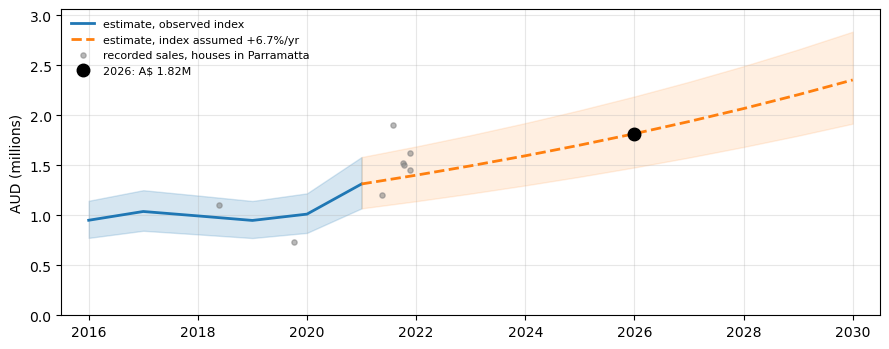

In [37]:
try:
    import ipywidgets as widgets
except ImportError:
    ensure("ipywidgets"); import ipywidgets as widgets
from IPython.display import display, HTML

YEAR_INDEX = sales.groupby(sales["date_sold"].dt.year)["property_inflation_index"].median()   # observed, 2016–2021 (2022 has 2 sales; dropped)
YEAR_INDEX = YEAR_INDEX[YEAR_INDEX.index <= 2021]
LAST_YEAR, LAST_INDEX = int(YEAR_INDEX.index[-1]), float(YEAR_INDEX.iloc[-1])
HIST_GROWTH = (LAST_INDEX / float(YEAR_INDEX.iloc[0])) ** (1 / (LAST_YEAR - int(YEAR_INDEX.index[0]))) - 1
YEARS = list(range(int(YEAR_INDEX.index[0]), 2031))

def index_for_year(year, growth):
    """Observed yearly index up to 2021, then extended at the assumed growth rate."""
    if year <= LAST_YEAR:
        return float(YEAR_INDEX.loc[year]), "observed"
    return LAST_INDEX * (1 + growth) ** (year - LAST_YEAR), f"projected at {100*growth:+.1f}%/yr"

def show_estimate(num_bed, num_bath, num_parking, property_size, type, suburb, year, growth_pct):
    growth = growth_pct / 100
    idx, how = index_for_year(year, growth)
    try:
        r = estimate_price(num_bed, num_bath, num_parking, property_size, type, suburb, idx)
    except ValueError as e:
        display(HTML(f"<p style='color:#b00'>Input rejected: {e}</p>")); return

    # relative (index-free) predictions once; the year only rescales them
    row = pd.DataFrame([{"num_bed": num_bed, "num_bath": num_bath, "num_parking": num_parking,
                         "property_size": property_size, "type": type, **SUBURB_TABLE.loc[suburb].to_dict()}])
    X = final_frame(row)
    rel_point = float(final_model.predict(X)[0])
    rel_q = sorted(float(quantile_models[t].predict(X)[0]) for t in TAUS)      # q10, q25, q50, q75, q90
    idx_path = np.array([index_for_year(y, growth)[0] for y in YEARS])
    path_point = np.exp(rel_point) * idx_path
    path_q10, path_q90 = np.exp(rel_q[0]) * idx_path, np.exp(rel_q[-1]) * idx_path

    est, (q10, q90), q25 = r["estimate_aud"], r["interval_80pct_aud"], r["lending_value_q25_aud"]
    display(HTML(f"""
    <div style='font-family:sans-serif;line-height:1.5'>
      <div style='font-size:15px;color:#444'>Estimated price in <b>{year}</b></div>
      <div style='font-size:30px;font-weight:bold'>A$ {est:,.0f}</div>
      <div>80% interval <b>A$ {q10:,.0f} – {q90:,.0f}</b> &nbsp;·&nbsp; lending value (q25) <b>A$ {q25:,.0f}</b></div>
      <div style='color:#666'>{num_bed} bed · {num_bath} bath · {num_parking} parking · {property_size:,.0f} m² · {type} · {suburb}
      &nbsp;·&nbsp; price index {idx:.1f} ({how})</div>
    </div>"""))

    comps = sales[(sales["suburb"] == suburb) & (sales["type"] == type)]
    obs = np.array(YEARS) <= LAST_YEAR
    fig, ax = plt.subplots(figsize=(9, 3.6))
    yrs = np.array(YEARS)
    ax.fill_between(yrs[obs], path_q10[obs] / 1e6, path_q90[obs] / 1e6, color="tab:blue", alpha=0.18)
    ax.fill_between(yrs[~obs | (yrs == LAST_YEAR)], path_q10[~obs | (yrs == LAST_YEAR)] / 1e6,
                    path_q90[~obs | (yrs == LAST_YEAR)] / 1e6, color="tab:orange", alpha=0.12)
    ax.plot(yrs[obs], path_point[obs] / 1e6, color="tab:blue", lw=2, label="estimate, observed index")
    ax.plot(yrs[~obs | (yrs == LAST_YEAR)], path_point[~obs | (yrs == LAST_YEAR)] / 1e6, color="tab:orange", lw=2, ls="--",
            label=f"estimate, index assumed {100*growth:+.1f}%/yr")
    if len(comps):
        t = comps["date_sold"].dt.year + comps["date_sold"].dt.dayofyear / 366
        ax.scatter(t, comps["price"] / 1e6, s=14, color="grey", alpha=0.55, label=f"recorded sales, {type.split(' /')[0].lower()}s in {suburb}")
    ax.plot([year], [est / 1e6], "o", color="k", ms=9, zorder=5, label=f"{year}: A$ {est/1e6:.2f}M")
    ax.set_xlim(YEARS[0] - 0.5, YEARS[-1] + 0.5); ax.set_ylim(0, max(path_q90.max(), comps["price"].quantile(0.97) if len(comps) else 0) * 1.08 / 1e6)
    ax.set_ylabel("AUD (millions)"); ax.set_xticks(YEARS[::2]); ax.grid(alpha=0.3)
    ax.legend(loc="upper left", fontsize=8, frameon=False)
    plt.tight_layout(); plt.show()

style = {"description_width": "150px"}
controls = dict(
    suburb=widgets.Combobox(value="Parramatta", options=sorted(SUBURB_TABLE.index), description="suburb",
                            placeholder="type to search", ensure_option=True, style=style),
    type=widgets.Dropdown(value="House", options=CATEGORY_LEVELS["type"], description="type", style=style),
    num_bed=widgets.IntSlider(value=3, min=RULES["num_bed"][0], max=RULES["num_bed"][1], description="bedrooms", continuous_update=False, style=style),
    num_bath=widgets.IntSlider(value=2, min=RULES["num_bath"][0], max=RULES["num_bath"][1], description="bathrooms", continuous_update=False, style=style),
    num_parking=widgets.IntSlider(value=1, min=RULES["num_parking"][0], max=RULES["num_parking"][1], description="parking", continuous_update=False, style=style),
    property_size=widgets.IntSlider(value=450, min=RULES["property_size"][0], max=2000, step=10, description="land size (m²)", continuous_update=False, style=style),
    year=widgets.IntSlider(value=2026, min=YEARS[0], max=YEARS[-1], description="year", continuous_update=False, style=style),
    growth_pct=widgets.FloatSlider(value=round(100 * HIST_GROWTH, 1), min=-5, max=15, step=0.5, readout_format=".1f",
                                   description="market growth after 2021 (%/yr)", continuous_update=False, style=style),
)
ui = widgets.VBox([widgets.HBox([controls["suburb"], controls["type"]]),
                   widgets.HBox([controls["num_bed"], controls["num_bath"], controls["num_parking"]]),
                   widgets.HBox([controls["property_size"], controls["year"], controls["growth_pct"]])])
import os
IN_VSCODE = any(k.startswith("VSCODE_") for k in os.environ)   # Cursor / VS Code notebook front-end
if IN_VSCODE:
    # The built-in notebook view of Cursor/VS Code often stalls while loading ipywidgets from a CDN,
    # so show one static example here. Use Colab or Jupyter Lab for the live controls.
    print("Static example (interactive controls are available on Colab / Jupyter Lab):")
    show_estimate(3, 2, 1, 450, "House", "Parramatta", 2026, round(100 * HIST_GROWTH, 1))
else:
    out = widgets.interactive_output(show_estimate, controls)
    display(ui, out)
